# Explainable Credit-Default Prediction for Peer-to-Peer Lending
### Neurosymbolic XAI on the Bondora loan book (AUCML Lab, ESE Project)

**Application domain:** FinTech and credit risk  
**Sustainable Development Goals:** SDG 8 (Decent Work and Economic Growth) and SDG 10 (Reduced Inequalities)  
**Dataset:** Bondora public loan dataset (`Bondora_Loan_Data.zip`, 179,235 loans, 112 columns)  
**Team / PRNs / Division:** *(fill in before submission)*

---

## Problem statement
A peer-to-peer platform has to decide, within seconds, whether an applicant will repay. Get it wrong one way and investors lose money. Get it wrong the other way and a creditworthy person, often someone a bank would turn away, is shut out of finance. Black-box models can rank risk well, but nobody can tell a rejected applicant *why* they were rejected, and nobody can easily check whether the model is quietly leaning on something unfair.

This project builds a default-risk model and then opens it up with three explanation methods: **SHAP**, **LIME** and a **neurosymbolic layer** that ties the model to written-down credit rules.

## Why these two SDGs
| SDG | Target we speak to | How this project contributes |
|---|---|---|
| **8** Decent Work and Economic Growth | 8.10: widen access to financial services | Better risk ranking lets a lender say yes to more thin-file and first-time borrowers without taking on hidden losses. |
| **10** Reduced Inequalities | 10.3: equal opportunity, less inequality of outcome | Every decision comes with reasons a person can read and contest, and we audit the model by gender, age band and country. |

## Pipeline covered in this notebook
1. **Data preprocessing and EDA**
2. **ML analysis and choosing the best model**
3. **Explainable AI:** SHAP, LIME and neurosymbolic XAI (used instead of multimodal cross-attention mapping, which suits image or text inputs and not a tabular loan book)

Website building and deployment come later. Section 3.6 saves every artefact those steps will need.

## 0. Setup
Fixed random seeds are used everywhere, so a re-run gives the same numbers. The first cell installs any missing library, which matters on Google Colab.

In [ ]:
import importlib, subprocess, sys

for pkg, mod in [("shap", "shap"), ("lime", "lime"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All libraries available.")

import os, json, time, warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})

FIG_DIR, ART_DIR = "figures", "artifacts"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=150, bbox_inches="tight")

def note(text):
    display(Markdown(text))

### Shared helper module
Feature engineering, the clipping transformer and the symbolic rule book live in a small module, `loan_utils.py`. Putting them in a file (and not inside the notebook) means the saved model can be loaded later by the website without re-running anything. The cell below writes the file, so the notebook stays self-contained.

In [ ]:
%%writefile loan_utils.py
"""Shared helpers for the Bondora default-risk project.

Kept in a separate module so that the saved sklearn pipeline can be un-pickled
later (for example by the website in step 4) without re-running the notebook.
"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# ----------------------------------------------------------------------------
# Feature schema (application-time information only)
# ----------------------------------------------------------------------------
NUMERIC_RAW = [
    "Age", "AppliedAmount", "Amount", "Interest", "LoanDuration", "MonthlyPayment",
    "IncomeTotal", "ExistingLiabilities", "LiabilitiesTotal",
    "NoOfPreviousLoansBeforeLoan", "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan", "PreviousEarlyRepaymentsCountBeforeLoan",
]
BINARY = ["NewCreditCustomer"]
CATEGORICAL = [
    "Country", "VerificationType", "Education", "HomeOwnershipType",
    "EmploymentDurationCurrentEmployer", "CreditScoreFiAsiakasTietoRiskGrade",
    "CreditScoreEeMini",
]
ENGINEERED = ["PaymentToIncome", "LiabToIncome", "AmountToIncome", "GrantedRatio",
              "PrevRepaymentRatio"]
NUMERIC_ALL = NUMERIC_RAW + BINARY + ENGINEERED
RAW_INPUT_COLUMNS = NUMERIC_RAW + BINARY + CATEGORICAL


def _cat_to_str(s: pd.Series) -> pd.Series:
    """Turn a coded column into clean strings ('4.0' -> '4', NaN -> 'Missing')."""
    def conv(v):
        if pd.isna(v):
            return "Missing"
        if isinstance(v, (int, np.integer)):
            return str(int(v))
        if isinstance(v, (float, np.floating)):
            return str(int(v)) if float(v).is_integer() else str(v)
        return str(v)
    return s.map(conv)


def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Raw Bondora columns -> model-ready feature frame (row-wise, no fitting)."""
    X = raw[RAW_INPUT_COLUMNS].copy()
    X["NewCreditCustomer"] = X["NewCreditCustomer"].astype(int)

    # Data-quality rule: a live loan cannot have a monthly instalment of zero. Those rows are
    # an artefact of old records (see section 1.6) and are treated as missing.
    X["MonthlyPayment"] = X["MonthlyPayment"].where(X["MonthlyPayment"] > 0)

    # Domain rule: no previous loans means nothing was repaid before this loan.
    no_prev = X["NoOfPreviousLoansBeforeLoan"].fillna(0).eq(0)
    X.loc[no_prev & X["PreviousRepaymentsBeforeLoan"].isna(), "PreviousRepaymentsBeforeLoan"] = 0.0

    income = X["IncomeTotal"].where(X["IncomeTotal"] > 0)
    prev_amt = X["AmountOfPreviousLoansBeforeLoan"].where(X["AmountOfPreviousLoansBeforeLoan"] > 0)
    X["PaymentToIncome"] = X["MonthlyPayment"] / income
    X["LiabToIncome"] = X["LiabilitiesTotal"] / income
    X["AmountToIncome"] = X["Amount"] / income
    X["GrantedRatio"] = X["Amount"] / X["AppliedAmount"].where(X["AppliedAmount"] > 0)
    X["PrevRepaymentRatio"] = X["PreviousRepaymentsBeforeLoan"] / prev_amt
    X[ENGINEERED] = X[ENGINEERED].replace([np.inf, -np.inf], np.nan)

    for c in CATEGORICAL:
        X[c] = _cat_to_str(X[c])
    return X[NUMERIC_ALL + CATEGORICAL]


class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip each column to quantiles learned on the training data only."""

    def __init__(self, lower=0.005, upper=0.995):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0)
        self.hi_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


# ----------------------------------------------------------------------------
# Symbolic knowledge base (expert credit-risk rules, evaluated on engineer_features output)
# expected = direction an analyst would expect: +1 raises default risk, -1 lowers it
# ----------------------------------------------------------------------------
def _gt(col, thr):
    return lambda X: X[col].ge(thr).fillna(False)


RULEBOOK = [
    dict(name="HighPaymentBurden", expected=+1, features=["PaymentToIncome"],
         text="the new monthly instalment is at least 15% of monthly income",
         fn=_gt("PaymentToIncome", 0.15)),
    dict(name="HighLiabilityLoad", expected=+1, features=["LiabToIncome"],
         text="existing monthly liabilities are at least 40% of monthly income",
         fn=_gt("LiabToIncome", 0.40)),
    dict(name="LargeLoanVsIncome", expected=+1, features=["AmountToIncome"],
         text="the loan is at least 3 times the monthly income",
         fn=_gt("AmountToIncome", 3.0)),
    dict(name="HighInterestRate", expected=+1, features=["Interest"],
         text="the interest rate is at least 40% (lender priced the applicant as risky)",
         fn=_gt("Interest", 40.0)),
    dict(name="LongLoanTerm", expected=+1, features=["LoanDuration"],
         text="the loan term is 48 months or longer",
         fn=_gt("LoanDuration", 48)),
    dict(name="FirstTimeBorrower", expected=+1, features=["NewCreditCustomer"],
         text="the applicant is a new credit customer with no track record",
         fn=lambda X: X["NewCreditCustomer"].eq(1)),
    dict(name="ShortEmploymentTenure", expected=+1, features=["EmploymentDurationCurrentEmployer"],
         text="the applicant is on a trial period or has under one year with the current employer",
         fn=lambda X: X["EmploymentDurationCurrentEmployer"].isin(["TrialPeriod", "UpTo1Year"])),
    dict(name="ProvenRepayer", expected=-1, features=["PreviousRepaymentsBeforeLoan"],
         text="the applicant has already repaid 1000 or more on earlier loans",
         fn=_gt("PreviousRepaymentsBeforeLoan", 1000)),
    dict(name="LowIncome", expected=+1, features=["IncomeTotal"],
         text="monthly income is below 800",
         fn=lambda X: X["IncomeTotal"].lt(800).fillna(False)),
]


def symbolic_predicates(X: pd.DataFrame) -> pd.DataFrame:
    """Truth value (0/1) of every rule in RULEBOOK for each applicant."""
    return pd.DataFrame({r["name"]: r["fn"](X).astype(int) for r in RULEBOOK}, index=X.index)

In [ ]:
import importlib
import loan_utils as lu
importlib.reload(lu)
print("Helper module loaded. Rules in the symbolic knowledge base:", len(lu.RULEBOOK))

Helper module loaded. Rules in the symbolic knowledge base: 9


---
# 1. Data preprocessing and EDA

## 1.1 Load the data
`pandas` reads a single-file zip directly, so there is no need to unzip. Put `Bondora_Loan_Data.zip` next to the notebook (or upload it to Colab) and the next cell finds it.

In [ ]:
CANDIDATES = [
    "Bondora_Loan_Data.zip", "LoanData_Bondora.csv", "data/Bondora_Loan_Data.zip",
    "/content/Bondora_Loan_Data.zip", "/content/drive/MyDrive/Bondora_Loan_Data.zip",
    "/mnt/user-data/uploads/Bondora_Loan_Data.zip",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert DATA_PATH is not None, "Dataset not found. Place Bondora_Loan_Data.zip next to this notebook."

raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded from: {DATA_PATH}")
print(f"Shape: {raw.shape[0]:,} loans x {raw.shape[1]} columns")
print(f"Report date of the snapshot: {raw['ReportAsOfEOD'].iloc[0]}")
print(f"Memory: {raw.memory_usage(deep=True).sum() / 1e6:,.0f} MB")

Loaded from: LoanData_Bondora.csv
Shape: 179,235 loans x 112 columns
Report date of the snapshot: 2021-07-20


Memory: 417 MB


## 1.2 Data quality audit
Before touching the target, we check what is empty, constant or duplicated. A 112-column table from a live lending platform always has surprises.

In [ ]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_%": raw.isna().mean() * 100,
    "unique_values": raw.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)

empty_cols = audit.index[audit["missing_%"] == 100].tolist()
constant_cols = audit.index[audit["unique_values"] <= 1].tolist()

print(f"Fully empty columns   ({len(empty_cols)}): {empty_cols}")
print(f"Constant columns      ({len(constant_cols)}): {constant_cols}")
print(f"Duplicate LoanId rows : {raw['LoanId'].duplicated().sum()}")
print(f"Fully duplicated rows : {raw.drop(columns=['LoanId', 'LoanNumber']).duplicated().sum()}")
print(f"Columns with any missing value: {(audit['missing_%'] > 0).sum()} of {len(audit)}")
display(audit.head(20))

Fully empty columns   (4): ['EmploymentPosition', 'County', 'City', 'DateOfBirth']
Constant columns      (5): ['EmploymentPosition', 'County', 'City', 'DateOfBirth', 'ReportAsOfEOD']
Duplicate LoanId rows : 0


Fully duplicated rows : 0
Columns with any missing value: 69 of 112


,dtype,missing_%,unique_values
EmploymentPosition,float64,100.0000,0
County,float64,100.0000,0
City,float64,100.0000,0
DateOfBirth,float64,100.0000,0
Rating_V0,str,97.4508,8
EL_V0,float64,97.4508,1203
CreditScoreEsEquifaxRisk,str,93.1827,6
Rating_V1,str,92.7894,8
EL_V1,float64,92.7894,1915
Rating_V2,str,85.9720,8


Four columns are completely empty (the only other constant column is the report date itself), and there are no duplicate loans. Most of the heavy missingness sits in columns that only exist *after* a loan has gone bad (default dates, recovery amounts, debt days), which already hints at the leakage problem we deal with next.

## 1.3 Defining the target
**Question the model answers:** *at application time, will this loan end in default?*

Bondora's `DefaultDate` is filled in once a loan is more than 60 days overdue, so `Default = DefaultDate is present` is a clean, observable event. Two traps need handling before we trust that label.

In [ ]:
raw["LoanDate"] = pd.to_datetime(raw["LoanDate"])
raw["LoanYear"] = raw["LoanDate"].dt.year
raw["DefaultFlag"] = raw["DefaultDate"].notna().astype(int)
REPORT_DATE = pd.to_datetime(raw["ReportAsOfEOD"].iloc[0])

print("Status versus default flag (all 179,235 loans):")
display(pd.crosstab(raw["Status"], raw["DefaultFlag"], margins=True))

Status versus default flag (all 179,235 loans):


DefaultFlag,0,1,All
Status,,,
Current,57611,163,57774
Late,8064,60510,68574
Repaid,42144,10743,52887
All,107819,71416,179235


**Trap 1, loans with no outcome yet.** A loan marked `Current` that has not defaulted is not a "good" loan, it is a loan whose story is still unfinished. The same holds for `Late` loans that have not yet crossed the 60-day line. Treating them as repaid would teach the model that unfinished means safe. We keep only loans with a **final** outcome: defaulted, or fully `Repaid` with no default.

**Trap 2, not enough time to default.** Even a healthy-looking cohort can look better than it is simply because it is young. We measure how long defaults usually take and keep only loans that have had at least a year of exposure before the snapshot date.

Days from loan start to default:
count   71,416.0000
mean       372.0000
std        284.0000
min         49.0000
10%        120.0000
25%        166.0000
50%        292.0000
75%        480.0000
90%        721.0000
95%        930.0000
max      2,922.0000

Snapshot date      : 2021-07-20
Seasoning cutoff   : loans issued on or before 2020-07-20


,step,loans,removed
0,All loans,179235,0
1,Keep only loans with a final outcome,113560,65675
2,Keep only loans with 12+ months of exposure,110342,3218



Modelling population: 110,342 loans, default rate 64.1%


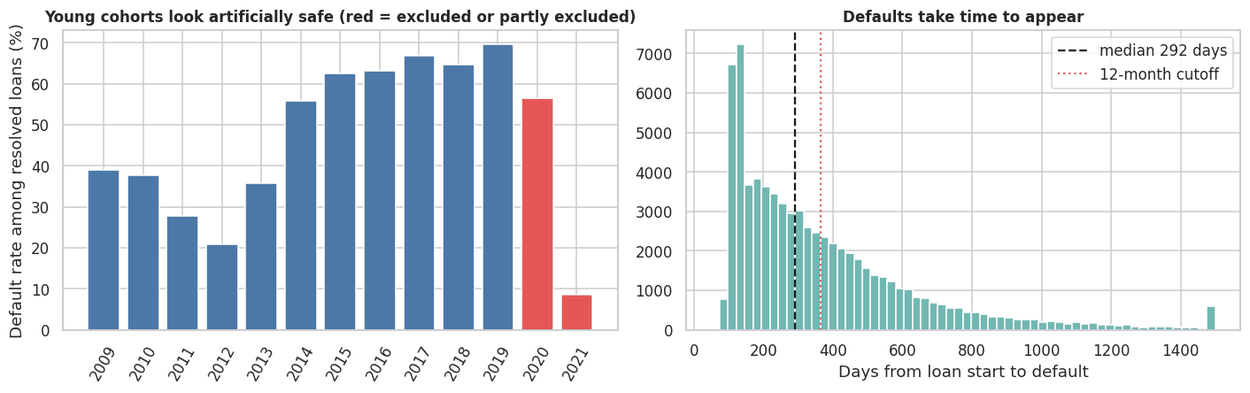

In [ ]:
days_to_default = (pd.to_datetime(raw["DefaultDate"]) - raw["LoanDate"]).dt.days.dropna()
print("Days from loan start to default:")
print(days_to_default.describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(0).to_string())

SEASONING_CUTOFF = REPORT_DATE - pd.DateOffset(months=12)
print(f"\nSnapshot date      : {REPORT_DATE.date()}")
print(f"Seasoning cutoff   : loans issued on or before {SEASONING_CUTOFF.date()}")

is_resolved = (raw["DefaultFlag"] == 1) | (raw["Status"] == "Repaid")
is_seasoned = raw["LoanDate"] <= SEASONING_CUTOFF

steps = pd.DataFrame({
    "step": ["All loans", "Keep only loans with a final outcome", "Keep only loans with 12+ months of exposure"],
    "loans": [len(raw), int(is_resolved.sum()), int((is_resolved & is_seasoned).sum())],
})
steps["removed"] = (-steps["loans"].diff()).fillna(0).astype(int)
display(steps)

model_df = raw.loc[is_resolved & is_seasoned].copy()
print(f"\nModelling population: {len(model_df):,} loans, default rate {model_df['DefaultFlag'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

by_year = raw.loc[is_resolved].groupby("LoanYear")["DefaultFlag"].agg(["mean", "size"])
colors = ["#4C78A8" if (pd.Timestamp(year=y, month=12, day=31) <= SEASONING_CUTOFF) else "#E45756" for y in by_year.index]
axes[0].bar(by_year.index.astype(str), by_year["mean"] * 100, color=colors)
axes[0].set_ylabel("Default rate among resolved loans (%)")
axes[0].set_title("Young cohorts look artificially safe (red = excluded or partly excluded)")
axes[0].tick_params(axis="x", rotation=60)

axes[1].hist(days_to_default.clip(upper=1500), bins=60, color="#72B7B2")
axes[1].axvline(days_to_default.median(), color="k", ls="--", label=f"median {days_to_default.median():.0f} days")
axes[1].axvline(365, color="#E45756", ls=":", label="12-month cutoff")
axes[1].set_xlabel("Days from loan start to default")
axes[1].set_title("Defaults take time to appear")
axes[1].legend()
plt.tight_layout(); save_fig(fig, "02_target_censoring"); plt.show()

The 2021 cohort shows a default rate under 10%, which says nothing about quality and everything about age. The 12-month rule removes that distortion. It does not remove it entirely, since roughly half of all defaults happen after the first 290 days or so. That is a real limitation, and we come back to it with a time-based validation in Section 2.7.

One more honest caveat: because unfinished loans are excluded, the default rate in our population (about 64%) is higher than the platform-wide rate. The model therefore ranks risk **among loans that reached a final outcome**. That is the standard setup for "fully paid versus charged off" credit studies.

## 1.4 Leakage control and column governance
This is the step that makes or breaks a credit model. A column is allowed in only if it is **known at application time**. The 112 columns fall into eleven groups. The code below forces every column into exactly one group, so nothing slips through unnoticed.

In [ ]:
FEATURE_COLS = lu.RAW_INPUT_COLUMNS

DROP_GROUPS = {
    "Identifiers": (
        ["ReportAsOfEOD", "LoanId", "LoanNumber", "UserName"],
        "Identify a loan or person but carry no risk signal."),
    "Dates and process timestamps": (
        ["ListedOnUTC", "BiddingStartedOn", "LoanApplicationStartedDate", "FirstPaymentDate",
         "MaturityDate_Original", "MaturityDate_Last", "ContractEndDate"],
        "Raw dates act as a proxy for vintage. ContractEndDate is only known after the loan ends."),
    "Kept only as helper metadata": (
        ["LoanDate", "LoanYear", "DefaultFlag"],
        "Used to build the target, apply the seasoning rule and run the time-based validation. Never a model input."),
    "Empty columns": (
        ["DateOfBirth", "County", "City", "EmploymentPosition"],
        "100% missing."),
    "Protected attributes (audit only)": (
        ["Gender", "LanguageCode"],
        "Not given to the model. Gender is used later to audit fairness; language is a proxy for ethnicity."),
    "Investor-side bidding": (
        ["BidsPortfolioManager", "BidsApi", "BidsManual"],
        "Investor behaviour after the loan is listed, not applicant information."),
    "Lender's own risk model outputs": (
        ["Rating", "ModelVersion", "ProbabilityOfDefault", "ExpectedLoss", "LossGivenDefault",
         "ExpectedReturn", "EL_V0", "Rating_V0", "EL_V1", "Rating_V1", "Rating_V2"],
        "These are another model's verdict. Using them would mean copying a model instead of building one."),
    "Fields Bondora stopped collecting": (
        ["UseOfLoan", "MaritalStatus", "NrOfDependants", "EmploymentStatus", "WorkExperience", "OccupationArea"],
        "Filled for loans up to about 2016, blank afterwards. A model that needs them cannot score today's applicants."),
    "Structurally empty in recent loans": (
        ["IncomeFromPrincipalEmployer", "IncomeFromPension", "IncomeFromFamilyAllowance", "IncomeFromSocialWelfare",
         "IncomeFromLeavePay", "IncomeFromChildSupport", "IncomeOther", "RefinanceLiabilities",
         "DebtToIncome", "FreeCash"],
        "Verified in 1.5: a single constant value for every loan issued 2018 onwards."),
    "Process artefacts and weak fields": (
        ["ApplicationSignedHour", "ApplicationSignedWeekday", "MonthlyPaymentDay",
         "CreditScoreEsMicroL", "CreditScoreEsEquifaxRisk", "PreviousEarlyRepaymentsBefoleLoan"],
        "Hour of day or payment day have no credit meaning. The two Spanish bureau fields are about 98% one value or missing, and the early-repayment amount is 67% missing."),
    "Post-origination outcome and servicing (leakage)": (
        ["ActiveScheduleFirstPaymentReached", "PlannedPrincipalTillDate", "PlannedInterestTillDate", "LastPaymentOn",
         "CurrentDebtDaysPrimary", "DebtOccuredOn", "CurrentDebtDaysSecondary", "DebtOccuredOnForSecondary",
         "DefaultDate", "PrincipalOverdueBySchedule", "PlannedPrincipalPostDefault", "PlannedInterestPostDefault",
         "EAD1", "EAD2", "PrincipalRecovery", "InterestRecovery", "RecoveryStage", "StageActiveSince", "Status",
         "Restructured", "ActiveLateCategory", "WorseLateCategory", "PrincipalPaymentsMade",
         "InterestAndPenaltyPaymentsMade", "PrincipalWriteOffs", "InterestAndPenaltyWriteOffs", "PrincipalBalance",
         "InterestAndPenaltyBalance", "GracePeriodStart", "GracePeriodEnd", "NextPaymentDate", "NextPaymentNr",
         "NrOfScheduledPayments", "ReScheduledOn", "PrincipalDebtServicingCost",
         "InterestAndPenaltyDebtServicingCost", "ActiveLateLastPaymentCategory"],
        "Only exist because the loan has already been repaid, paid late or defaulted. Using any of them would make the model look brilliant and be useless."),
}

original_cols = [c for c in raw.columns if c not in ("LoanYear", "DefaultFlag")]
dropped = [c for cols, _ in DROP_GROUPS.values() for c in cols if c not in ("LoanYear", "DefaultFlag")]
overlap = set(FEATURE_COLS) & set(dropped)
unassigned = set(original_cols) - set(FEATURE_COLS) - set(dropped)
unknown = set(dropped) - set(original_cols)

assert not overlap, f"Columns both kept and dropped: {overlap}"
assert not unassigned, f"Columns not assigned to any group: {unassigned}"
assert not unknown, f"Group lists a column that does not exist: {unknown}"
print(f"Check passed: {len(FEATURE_COLS)} model inputs + {len(dropped)} governed columns = {len(original_cols)} original columns.\n")

gov = pd.DataFrame(
    [(g, len([c for c in cols if c not in ("LoanYear", "DefaultFlag")]), why) for g, (cols, why) in DROP_GROUPS.items()],
    columns=["Group dropped from model inputs", "columns", "Reason"])
display(gov.style.set_properties(subset=["Reason"], **{"white-space": "pre-wrap", "text-align": "left"}).hide(axis="index"))

Check passed: 21 model inputs + 91 governed columns = 112 original columns.



Group dropped from model inputs,columns,Reason
Identifiers,4,Identify a loan or person but carry no risk signal.
Dates and process timestamps,7,Raw dates act as a proxy for vintage. ContractEndDate is only known after the loan ends.
Kept only as helper metadata,1,"Used to build the target, apply the seasoning rule and run the time-based validation. Never a model input."
Empty columns,4,100% missing.
Protected attributes (audit only),2,Not given to the model. Gender is used later to audit fairness; language is a proxy for ethnicity.
Investor-side bidding,3,"Investor behaviour after the loan is listed, not applicant information."
Lender's own risk model outputs,11,These are another model's verdict. Using them would mean copying a model instead of building one.
Fields Bondora stopped collecting,6,"Filled for loans up to about 2016, blank afterwards. A model that needs them cannot score today's applicants."
Structurally empty in recent loans,10,Verified in 1.5: a single constant value for every loan issued 2018 onwards.
Process artefacts and weak fields,6,"Hour of day or payment day have no credit meaning. The two Spanish bureau fields are about 98% one value or missing, and the early-repayment amount is 67% missing."


## 1.5 Check that the kept features are really usable today
The "structurally empty" group was a judgement from looking at the data. Here it is verified rather than assumed: for every application-time column, we look at loans issued 2018 to 2020 only (the regime a live model would face) and measure how much of the column is missing and how dominant its most common value is.

In [ ]:
recent = raw[raw["LoanYear"].between(2018, 2020)]
candidates = FEATURE_COLS + ["DebtToIncome", "FreeCash", "RefinanceLiabilities", "IncomeFromPrincipalEmployer",
                              "IncomeFromPension", "IncomeFromFamilyAllowance", "IncomeFromSocialWelfare",
                              "IncomeFromLeavePay", "IncomeFromChildSupport", "IncomeOther",
                              "CreditScoreEsMicroL", "CreditScoreEsEquifaxRisk"]
rows = []
for c in candidates:
    s = recent[c]
    top_share = s.value_counts(dropna=False, normalize=True).iloc[0] * 100
    rows.append((c, s.isna().mean() * 100, top_share, s.nunique()))
avail = pd.DataFrame(rows, columns=["column", "missing_%", "most_common_value_%", "unique_values"]).set_index("column")
avail["verdict"] = np.where(
    (avail["unique_values"] <= 1) | (avail["most_common_value_%"] >= 97) | (avail["missing_%"] >= 95),
    "unusable today", "usable")

kept_flagged = avail.loc[FEATURE_COLS].query("verdict == 'unusable today'")
print("Kept features flagged unusable:", kept_flagged.index.tolist())
dropped_ok = avail.drop(index=FEATURE_COLS)
print("Dropped-for-availability columns that really are unusable:", (dropped_ok["verdict"] == "unusable today").sum(), "of", len(dropped_ok))
display(avail.sort_values("most_common_value_%", ascending=False).head(18))

Kept features flagged unusable: []
Dropped-for-availability columns that really are unusable: 12 of 12


,missing_%,most_common_value_%,unique_values,verdict
column,,,,
IncomeFromPension,0.0000,100.0000,1,unusable today
RefinanceLiabilities,0.0000,100.0000,1,unusable today
IncomeFromFamilyAllowance,0.0000,100.0000,1,unusable today
IncomeFromSocialWelfare,0.0000,100.0000,1,unusable today
IncomeFromLeavePay,0.0000,100.0000,1,unusable today
DebtToIncome,0.0000,100.0000,1,unusable today
FreeCash,0.0000,100.0000,1,unusable today
IncomeOther,0.0000,100.0000,1,unusable today
IncomeFromChildSupport,0.0000,100.0000,1,unusable today


Everything we dropped for availability reasons is confirmed unusable in recent loans: ten columns hold one constant value, and the two Spanish bureau fields are almost all one value or missing. None of the kept features is flagged. The closest call is `PreviousEarlyRepaymentsCountBeforeLoan` at about 96% one value (most loans simply have zero early repayments, a genuine "no" and not missing information), so it stays.

Two things worth knowing about what *is* kept. `CreditScoreFiAsiakasTietoRiskGrade` and `CreditScoreEeMini` are bureau scores that exist only for Finnish and Estonian applicants, so a blank is "not applicable" and becomes its own category. `DebtToIncome` and `FreeCash` look like the most natural credit variables, but they are blank-as-zero for all recent loans, so we rebuild affordability from fields that are populated: payment, liabilities and loan amount divided by income.

## 1.6 Feature engineering
Five ratio features turn raw amounts into affordability signals (`engineer_features` in `loan_utils.py`):

| Feature | Meaning |
|---|---|
| `PaymentToIncome` | new monthly instalment divided by monthly income |
| `LiabToIncome` | existing monthly liabilities divided by monthly income |
| `AmountToIncome` | loan size in months of income |
| `GrantedRatio` | amount granted divided by amount requested |
| `PrevRepaymentRatio` | share of earlier borrowing already repaid |

Two domain rules are applied while building them. If a person had no earlier loans, then "previous repayments" is zero, not unknown. And a monthly instalment of exactly zero is treated as missing, for the reason the next cell shows.

In [ ]:
zero_pay = model_df["MonthlyPayment"].eq(0)
print(f"Loans with a monthly payment of exactly 0: {zero_pay.sum():,} ({zero_pay.mean():.1%} of the modelling population)")
print(f"  share issued in 2013-2014 : {model_df.loc[zero_pay, 'LoanYear'].isin([2013, 2014]).mean():.1%}")
print(f"  default rate when payment is 0 : {model_df.loc[zero_pay, 'DefaultFlag'].mean():.1%}   (population: {model_df['DefaultFlag'].mean():.1%})")
print(f"  default rate when payment is missing : {model_df.loc[model_df['MonthlyPayment'].isna(), 'DefaultFlag'].mean():.1%}")

Loans with a monthly payment of exactly 0: 3,551 (3.2% of the modelling population)
  share issued in 2013-2014 : 97.3%
  default rate when payment is 0 : 80.7%   (population: 64.1%)
  default rate when payment is missing : 24.9%


**What this shows.** A payment of exactly zero is not a person with no instalment. Almost all of these loans (97%) were issued in 2013 and 2014, and they default far more often (80.7%) than the population (64.1%). A model that sees a zero can simply learn "this is a 2013 loan" and use that as a shortcut. Treating it as missing removes the shortcut. After the fix these loans are merged with the ones where the payment is genuinely blank (those behave very differently, at 24.9% default), so the shortcut is gone at the price of a little noise.

In [ ]:
X_all = lu.engineer_features(model_df)
y_all = model_df["DefaultFlag"].astype(int)

assert X_all.index.equals(y_all.index)
assert not np.isinf(X_all[lu.NUMERIC_ALL].to_numpy(dtype=float)).any(), "infinite values found"

schema = pd.DataFrame({
    "type": ["numeric" if c in lu.NUMERIC_ALL else "categorical" for c in X_all.columns],
    "missing_%": X_all.isna().mean() * 100,
    "unique": X_all.nunique(),
})
print(f"Feature matrix: {X_all.shape[0]:,} rows x {X_all.shape[1]} features "
      f"({len(lu.NUMERIC_ALL)} numeric, {len(lu.CATEGORICAL)} categorical)")
display(schema)

Feature matrix: 110,342 rows x 26 features (19 numeric, 7 categorical)


,type,missing_%,unique
Age,numeric,0.0000,62
AppliedAmount,numeric,0.0000,591
Amount,numeric,0.0000,5198
Interest,numeric,0.0000,6689
LoanDuration,numeric,0.0000,32
MonthlyPayment,numeric,9.2530,23819
IncomeTotal,numeric,0.0000,3998
ExistingLiabilities,numeric,0.0000,39
LiabilitiesTotal,numeric,0.0000,39324
NoOfPreviousLoansBeforeLoan,numeric,0.0073,26


## 1.7 Train and test split
The test set is locked away *now*, before any exploration or fitting. Everything learned from data from here on (EDA statistics, clipping limits, imputation values, model choice, rule thresholds) comes from the training set only. The split is stratified so both parts keep the same default rate.

The protected attributes and the loan year are carried alongside, not inside, the features. They are used later for fairness checks and time-based validation.

In [ ]:
from sklearn.model_selection import train_test_split

meta_all = model_df[["LoanYear", "Gender", "Age", "Country"]].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED)
meta_train, meta_test = meta_all.loc[X_train.index], meta_all.loc[X_test.index]

print(f"Train: {len(X_train):,} loans, default rate {y_train.mean():.2%}")
print(f"Test : {len(X_test):,} loans, default rate {y_test.mean():.2%}")
assert set(X_train.index).isdisjoint(X_test.index)

Train: 88,273 loans, default rate 64.08%
Test : 22,069 loans, default rate 64.08%


## 1.8 Exploratory data analysis (training data only)
### Who defaults? Categorical view

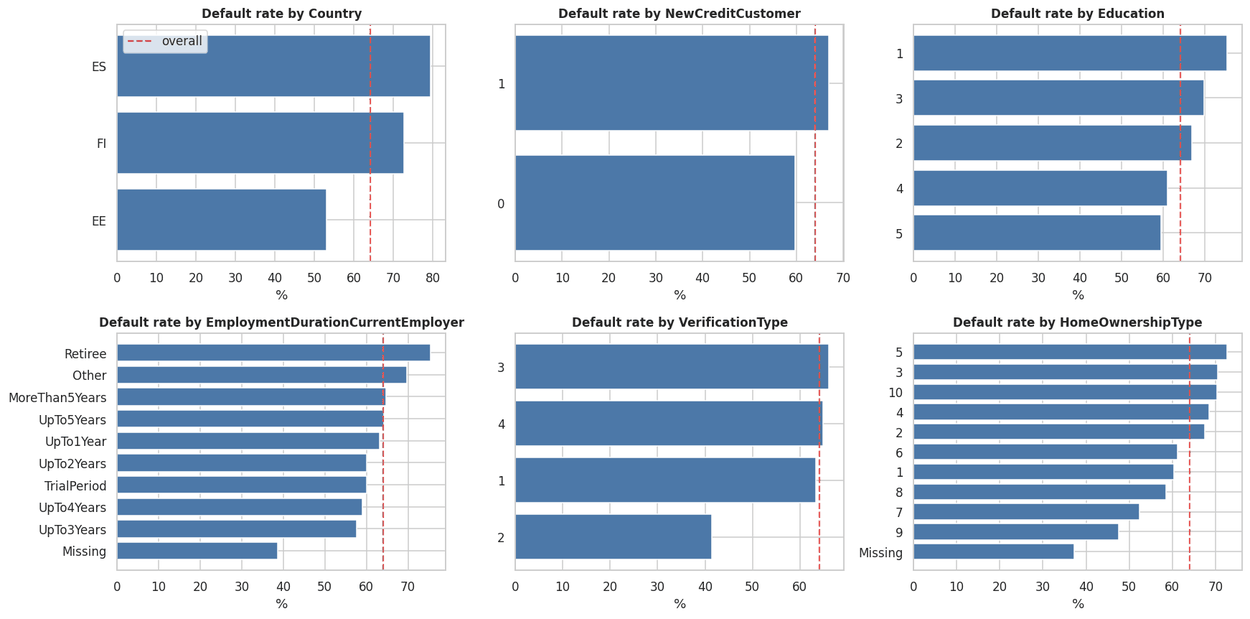

In [ ]:
eda = X_train.copy()
eda["Default"] = y_train
base_rate = y_train.mean()

cat_view = ["Country", "NewCreditCustomer", "Education", "EmploymentDurationCurrentEmployer", "VerificationType", "HomeOwnershipType"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cat_view):
    g = eda.groupby(col)["Default"].agg(["mean", "size"])
    g = g[g["size"] >= 300].sort_values("mean")
    ax.barh(g.index.astype(str), g["mean"] * 100, color="#4C78A8")
    ax.axvline(base_rate * 100, color="#E45756", ls="--", label="overall")
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("%")
axes[0, 0].legend()
plt.tight_layout(); save_fig(fig, "03_eda_categorical"); plt.show()

**Reading the categorical view.** Geography dominates. In the training data about 53% of Estonian loans default, against 73% in Finland and 79% in Spain, so a single global cut-off will treat these markets very differently (this becomes the central fairness issue in 3.5). New credit customers default more than returning ones (66.9% against 59.7%). The education code shows a broad downward slope, from 75.2% at code 1 to 59.5% at code 5. Retirees sit at 75.4%. A few bars look dramatic (a very low rate for one verification code, or for blank employment tenure) but rest on small groups, which is why bars under 300 loans are hidden or should be read with care.

### Who defaults? Numeric view
Each panel cuts a numeric feature into equal-sized buckets and shows the default rate in each. A steady slope means the feature carries signal that a model (and a rule) can use.

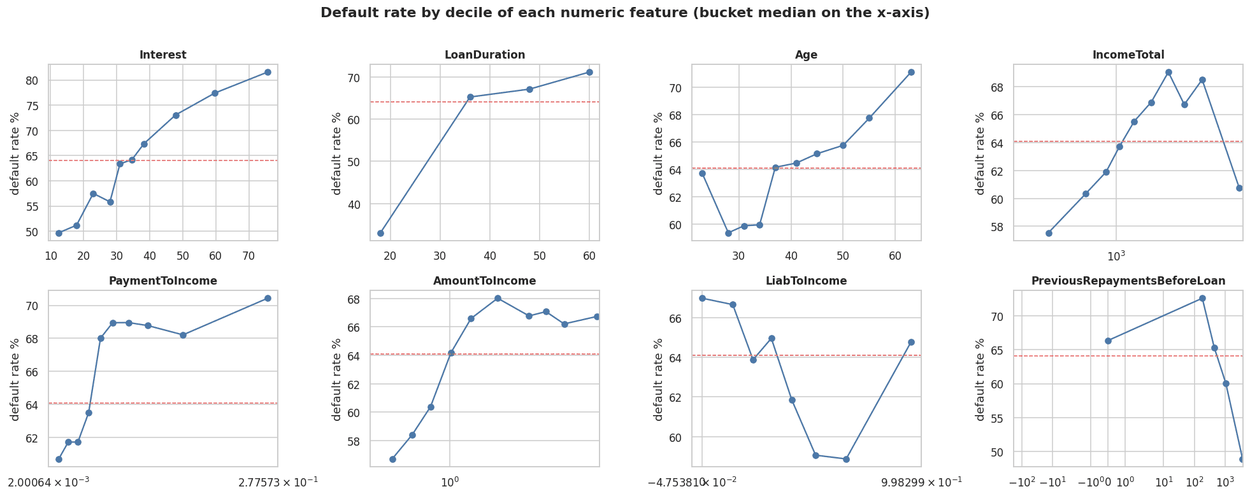

In [ ]:
def rate_by_bucket(df, col, q=10):
    s = df[col]
    bins = pd.qcut(s, q=q, duplicates="drop")
    g = df.groupby(bins, observed=True)["Default"].mean() * 100
    mid = df.groupby(bins, observed=True)[col].median()
    return mid.values, g.values

num_view = ["Interest", "LoanDuration", "Age", "IncomeTotal", "PaymentToIncome", "AmountToIncome", "LiabToIncome", "PreviousRepaymentsBeforeLoan"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), num_view):
    x, yv = rate_by_bucket(eda.dropna(subset=[col]), col, q=10)
    ax.plot(x, yv, marker="o", color="#4C78A8")
    ax.axhline(base_rate * 100, color="#E45756", ls="--", lw=1)
    ax.set_title(col)
    ax.set_ylabel("default rate %")
    if col in ("IncomeTotal", "PreviousRepaymentsBeforeLoan", "AmountToIncome", "LiabToIncome", "PaymentToIncome"):
        ax.set_xscale("symlog")
plt.suptitle("Default rate by decile of each numeric feature (bucket median on the x-axis)", y=1.01, fontweight="bold")
plt.tight_layout(); save_fig(fig, "04_eda_numeric_deciles"); plt.show()

**Reading the numeric view.** Two features move default risk in a clean, steady way. The default rate climbs from about 50% in the cheapest fifth of interest rates to about 80% in the dearest fifth, and loan term matters even more: 28.5% for terms up to a year, 71.1% for terms above 48 months. Income is the odd one out. Default rises with income up to the fourth fifth (59% to 68%) and then falls back (64.7%), so income on its own is a weak and confounded signal. That matters later, when an "expert" rule about low income meets the data.

### Outliers

In [ ]:
num_cols = lu.NUMERIC_ALL
p995 = X_train[num_cols].quantile(0.995)
outlier = pd.DataFrame({
    "99.5th pct": p995,
    "max": X_train[num_cols].max(),
    "max / 99.5th pct": X_train[num_cols].max() / p995.replace(0, np.nan),
    "% above 99.5th pct": (X_train[num_cols].gt(p995)).mean() * 100,
}).sort_values("max / 99.5th pct", ascending=False)
note("**Features whose maximum is far beyond the 99.5th percentile** (these are clipped in the pipeline, see 1.9):")
display(outlier.head(8))

**Features whose maximum is far beyond the 99.5th percentile** (these are clipped in the pipeline, see 1.9):

,99.5th pct,max,max / 99.5th pct,% above 99.5th pct
LiabilitiesTotal,"3,493.0892","12,400,000.0000","3,549.8664",0.5007
LiabToIncome,1.8580,"6,526.3158","3,512.6193",0.5007
AmountToIncome,10.6250,"2,252.1739",211.9693,0.4996
PaymentToIncome,0.4955,75.0435,151.4468,0.4543
IncomeTotal,"16,632.0000","1,012,019.0000",60.8477,0.5007
PreviousEarlyRepaymentsCountBeforeLoan,2.0000,11.0000,5.5000,0.4203
MonthlyPayment,648.9153,"2,277.3200",3.5094,0.4543
AmountOfPreviousLoansBeforeLoan,"21,537.8250","68,114.0000",3.1625,0.5007


### Correlation structure

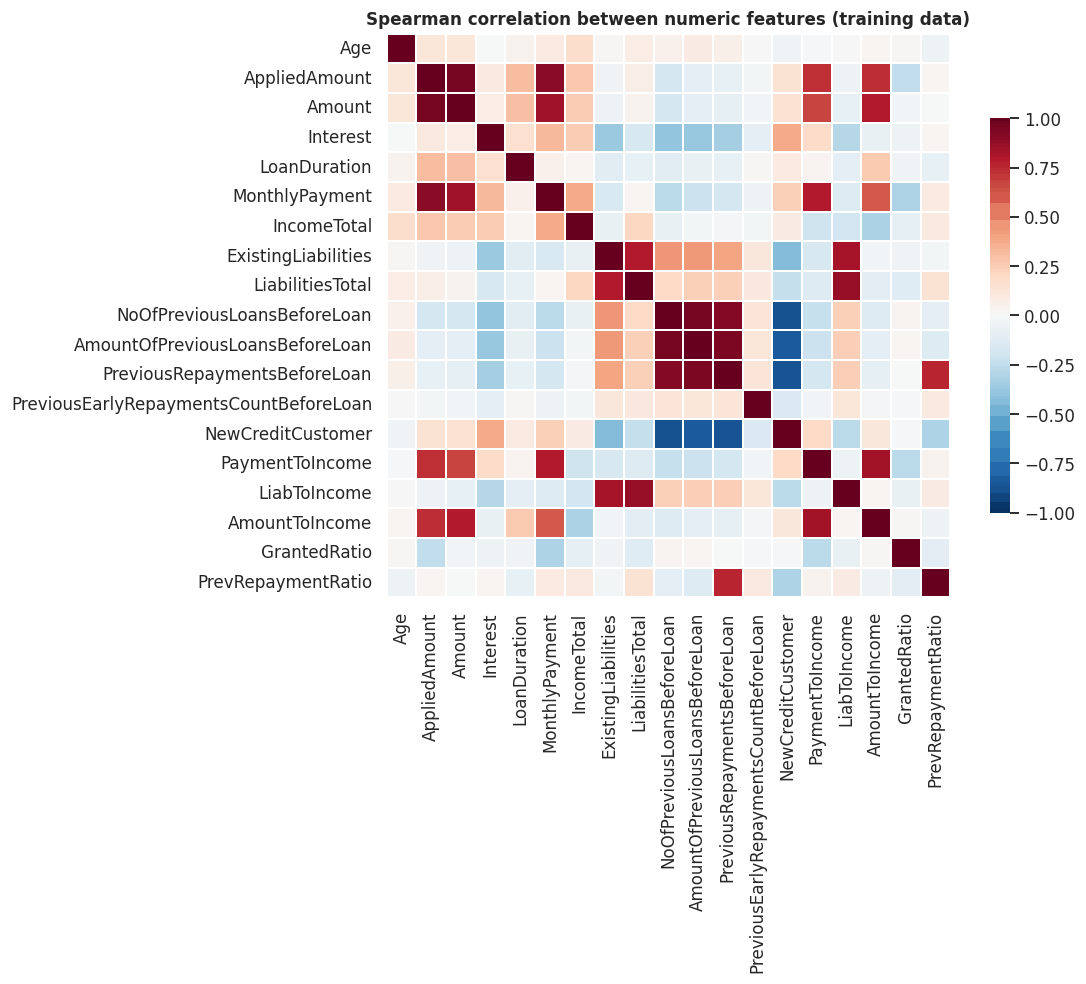

**Feature pairs with |Spearman| >= 0.80** (redundant information; harmless for tree models, a nuisance for linear ones):

,,spearman
NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,0.9575
AppliedAmount,Amount,0.9544
AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,0.9408
NoOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,0.9197
AppliedAmount,MonthlyPayment,0.9055
LiabilitiesTotal,LiabToIncome,0.8741
NoOfPreviousLoansBeforeLoan,NewCreditCustomer,-0.8696
PreviousRepaymentsBeforeLoan,NewCreditCustomer,-0.8619
Amount,MonthlyPayment,0.8500
AmountOfPreviousLoansBeforeLoan,NewCreditCustomer,-0.8419


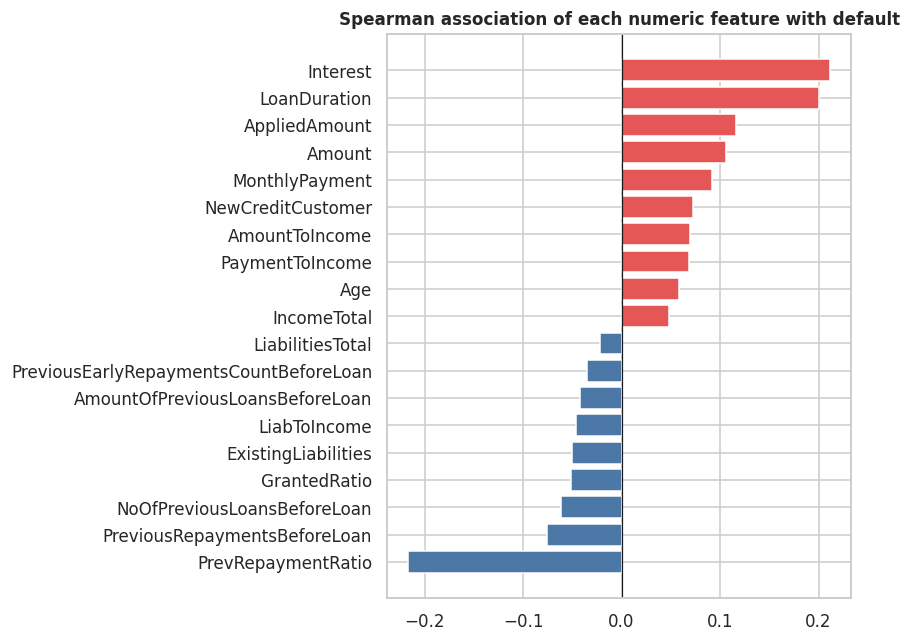

In [ ]:
corr = X_train[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=.3,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Spearman correlation between numeric features (training data)")
plt.tight_layout(); save_fig(fig, "06_eda_correlation"); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
high = pairs[pairs.abs() >= 0.80].sort_values(key=np.abs, ascending=False)
note("**Feature pairs with |Spearman| >= 0.80** (redundant information; harmless for tree models, a nuisance for linear ones):")
display(high.rename("spearman").to_frame())

assoc = X_train[num_cols].apply(lambda s: s.corr(y_train, method="spearman")).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(assoc.index, assoc.values, color=np.where(assoc.values > 0, "#E45756", "#4C78A8"))
ax.set_title("Spearman association of each numeric feature with default")
ax.axvline(0, color="k", lw=.8)
plt.tight_layout(); save_fig(fig, "07_eda_target_association"); plt.show()

**Reading the correlations.** Most redundancy is structural and harmless. The number of previous loans, the amount borrowed before, and the amount repaid before are almost the same variable (Spearman 0.92 to 0.96), the requested and granted amounts are nearly identical (0.95), and "new customer" is close to the mirror image of "has previous loans" (about -0.87 by definition). Tree models do not mind this. The practical consequence is for explanation: when several features carry the same information, SHAP splits the credit between them, so each one looks less important than the group really is. Read importance for such groups together.

## 1.9 Preprocessing pipeline
Everything that learns from data lives inside one scikit-learn `ColumnTransformer`, fitted on training rows only:

* **Numeric:** clip to the 0.5th and 99.5th percentile (limits learned from the training set), then fill gaps with the training median.
* **Categorical:** one-hot encoding. Categories seen in less than 1% of training rows are pooled into one "infrequent" bucket, and anything unseen at prediction time falls into that bucket too. A blank is already an explicit `Missing` category.
* **Scaling** is added only for the two models that need it (logistic regression and the neural network).

Because the transformer is a step *inside* each model pipeline, cross-validation re-fits it on every fold. No information from a validation fold can leak into the clipping limits or the medians.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

def build_preprocessor(drop=()):
    num = [c for c in lu.NUMERIC_ALL if c not in drop]
    cat = [c for c in lu.CATEGORICAL if c not in drop]
    return ColumnTransformer([
        ("num", Pipeline([("clip", lu.Winsorizer(0.005, 0.995)),
                          ("impute", SimpleImputer(strategy="median"))]), num),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False), cat),
    ], verbose_feature_names_out=False)

def build_pipe(estimator, scale=False, drop=()):
    steps = [("prep", build_preprocessor(drop))]
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("clf", estimator))
    return Pipeline(steps)

demo_prep = build_preprocessor().fit(X_train)
A = demo_prep.transform(X_train)
feature_names = demo_prep.get_feature_names_out().tolist()
print(f"Transformed training matrix: {A.shape[0]:,} rows x {A.shape[1]} columns")
print("NaN left:", int(np.isnan(A).sum()), "| inf left:", int(np.isinf(A).sum()))
print("First 12 column names:", feature_names[:12])
print("Last 8 column names :", feature_names[-8:])

Transformed training matrix: 88,273 rows x 69 columns
NaN left: 0 | inf left: 0
First 12 column names: ['Age', 'AppliedAmount', 'Amount', 'Interest', 'LoanDuration', 'MonthlyPayment', 'IncomeTotal', 'ExistingLiabilities', 'LiabilitiesTotal', 'NoOfPreviousLoansBeforeLoan', 'AmountOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan']
Last 8 column names : ['CreditScoreFiAsiakasTietoRiskGrade_infrequent_sklearn', 'CreditScoreEeMini_1000', 'CreditScoreEeMini_600', 'CreditScoreEeMini_700', 'CreditScoreEeMini_800', 'CreditScoreEeMini_900', 'CreditScoreEeMini_Missing', 'CreditScoreEeMini_infrequent_sklearn']


---
# 2. ML analysis: choosing the best model

## 2.1 The candidates and the yardsticks
Seven model families, from a transparent baseline to a neural network. All use the same preprocessing and the same five cross-validation folds on the training set.

| Model | Why it is in the race |
|---|---|
| Logistic Regression | The classic scorecard. Interpretable floor to beat. |
| Decision Tree | Readable rules, but unstable. |
| Random Forest | Strong bagging baseline. |
| Hist Gradient Boosting | scikit-learn's native boosting. |
| XGBoost | Industry-standard boosting. |
| LightGBM | Fast boosting with good handling of mixed data. |
| Neural Network (MLP) | The sub-symbolic learner most associated with "black box". |

**Metrics.** The positive class is *default*. ROC-AUC is the headline because it does not depend on a cut-off and the classes are not balanced (64/36). PR-AUC, F1, balanced accuracy and MCC show the picture at a 0.5 threshold, and the Brier score checks whether the predicted probabilities are honest.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import make_scorer, matthews_corrcoef
from scipy.stats import randint, uniform, loguniform

def make_models():
    return {
        "Logistic Regression": build_pipe(LogisticRegression(C=0.5, max_iter=1000), scale=True),
        "Decision Tree": build_pipe(DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=SEED)),
        "Random Forest": build_pipe(RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=SEED)),
        "Hist Gradient Boosting": build_pipe(HistGradientBoostingClassifier(random_state=SEED)),
        "XGBoost": build_pipe(XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8,
                                            colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=SEED)),
        "LightGBM": build_pipe(LGBMClassifier(n_estimators=400, learning_rate=0.05, subsample=0.8, subsample_freq=1,
                                              colsample_bytree=0.8, n_jobs=-1, verbose=-1, random_state=SEED,
                                              deterministic=True, force_row_wise=True)),
        "Neural Network (MLP)": build_pipe(MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True,
                                                         max_iter=200, random_state=SEED), scale=True),
    }

SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "bal_acc": "balanced_accuracy",
    "mcc": make_scorer(matthews_corrcoef),
    "brier": "neg_brier_score",
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_row(pipe):
    t0 = time.time()
    r = cross_validate(pipe, X_train, y_train, cv=cv5, scoring=SCORING, return_train_score=False, n_jobs=1)
    out = {
        "ROC-AUC": r["test_roc_auc"].mean(), "ROC-AUC std": r["test_roc_auc"].std(),
        "PR-AUC": r["test_pr_auc"].mean(), "F1@0.5": r["test_f1"].mean(),
        "Bal.Acc@0.5": r["test_bal_acc"].mean(), "MCC@0.5": r["test_mcc"].mean(),
        "Brier": -r["test_brier"].mean(), "fit+score s/fold": (r["fit_time"] + r["score_time"]).mean(),
    }
    return out

## 2.2 Five-fold cross-validation of all seven models

Logistic Regression      CV ROC-AUC = 0.7221 +/- 0.0023


Decision Tree            CV ROC-AUC = 0.7277 +/- 0.0017


Random Forest            CV ROC-AUC = 0.7668 +/- 0.0012


Hist Gradient Boosting   CV ROC-AUC = 0.7623 +/- 0.0016


XGBoost                  CV ROC-AUC = 0.7701 +/- 0.0016


LightGBM                 CV ROC-AUC = 0.7692 +/- 0.0013


Neural Network (MLP)     CV ROC-AUC = 0.7469 +/- 0.0021


,ROC-AUC,ROC-AUC std,PR-AUC,F1@0.5,Bal.Acc@0.5,MCC@0.5,Brier,fit+score s/fold
XGBoost,0.7701,0.0016,0.8360,0.8131,0.6766,0.3997,0.1787,6.8068
LightGBM,0.7692,0.0013,0.8351,0.8137,0.6777,0.4019,0.1791,4.9747
Random Forest,0.7668,0.0012,0.8300,0.8147,0.6723,0.3979,0.1806,27.1318
Hist Gradient Boosting,0.7623,0.0016,0.8291,0.8101,0.6694,0.3864,0.1818,4.0325
Neural Network (MLP),0.7469,0.0021,0.8167,0.8027,0.6646,0.3694,0.1875,5.0486
Decision Tree,0.7277,0.0017,0.7949,0.8008,0.6458,0.3427,0.1925,1.3809
Logistic Regression,0.7221,0.0023,0.7960,0.7964,0.6450,0.3341,0.1951,0.9606


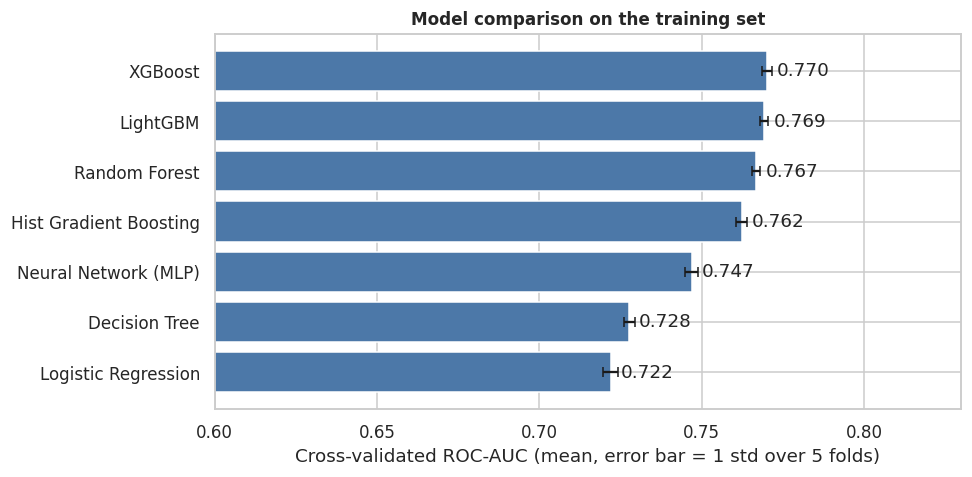

In [ ]:
baseline = {}
models = make_models()
for name, pipe in models.items():
    baseline[name] = cv_row(pipe)
    print(f"{name:<24} CV ROC-AUC = {baseline[name]['ROC-AUC']:.4f} +/- {baseline[name]['ROC-AUC std']:.4f}")

cv_table = pd.DataFrame(baseline).T.sort_values("ROC-AUC", ascending=False)
display(cv_table)

fig, ax = plt.subplots(figsize=(9, 4.5))
order = cv_table.sort_values("ROC-AUC")
ax.barh(order.index, order["ROC-AUC"], xerr=order["ROC-AUC std"], color="#4C78A8", capsize=3)
for i, v in enumerate(order["ROC-AUC"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center")
ax.set_xlim(0.6, 0.83)
ax.set_xlabel("Cross-validated ROC-AUC (mean, error bar = 1 std over 5 folds)")
ax.set_title("Model comparison on the training set")
plt.tight_layout(); save_fig(fig, "08_model_comparison"); plt.show()

**What the comparison says.** XGBoost, LightGBM and the random forest sit clearly above everything else (0.767 to 0.770 ROC-AUC), with histogram boosting just behind (0.762), and the fold-to-fold spread is small, with a standard deviation of only 0.001 to 0.002, so gaps of that size or larger are real. XGBoost and LightGBM are separated by 0.0009, which is noise. The jump from logistic regression (0.722) to boosting (0.770) is about five points and tells us the problem is not linear: loan term, for instance, behaves like a set of steps and not a slope, and risk depends on how country, term and interest combine. The neural network (0.747) lands between the linear model and the trees, a common result on mixed tabular data of this size.

## 2.3 Tuning the two strongest candidates
The two best models by cross-validated ROC-AUC get a randomised hyper-parameter search (8 draws, 3-fold inside the training set). The tuned versions are then re-scored on the **same** 5 folds as everything else, so the comparison stays fair. The test set has still not been touched.

In [ ]:
SPACES = {
    "XGBoost": {
        "clf__n_estimators": randint(200, 700), "clf__learning_rate": uniform(0.02, 0.08),
        "clf__max_depth": randint(3, 9), "clf__min_child_weight": randint(1, 25),
        "clf__subsample": uniform(0.6, 0.4), "clf__colsample_bytree": uniform(0.5, 0.5),
        "clf__reg_lambda": loguniform(0.5, 10)},
    "LightGBM": {
        "clf__n_estimators": randint(200, 700), "clf__learning_rate": uniform(0.02, 0.08),
        "clf__num_leaves": randint(15, 127), "clf__min_child_samples": randint(20, 200),
        "clf__subsample": uniform(0.6, 0.4), "clf__colsample_bytree": uniform(0.5, 0.5),
        "clf__reg_lambda": loguniform(0.1, 10)},
    "Hist Gradient Boosting": {
        "clf__learning_rate": uniform(0.03, 0.1), "clf__max_leaf_nodes": randint(15, 80),
        "clf__min_samples_leaf": randint(20, 200), "clf__l2_regularization": loguniform(0.01, 10),
        "clf__max_iter": randint(150, 500)},
    "Random Forest": {
        "clf__n_estimators": randint(150, 300), "clf__max_depth": randint(8, 25),
        "clf__min_samples_leaf": randint(2, 30), "clf__max_features": uniform(0.2, 0.5)},
}
top2 = [n for n in cv_table.index if n in SPACES][:2]
print("Tuning:", top2)

tuned_pipes, tune_log = {}, []
for name in top2:
    t0 = time.time()
    search = RandomizedSearchCV(
        make_models()[name], SPACES[name], n_iter=8,
        cv=StratifiedKFold(3, shuffle=True, random_state=SEED), scoring="roc_auc",
        random_state=SEED, n_jobs=1, refit=False)
    search.fit(X_train, y_train)
    best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    tuned = make_models()[name].set_params(**search.best_params_)
    tuned_pipes[name + " (tuned)"] = tuned
    tune_log.append({"model": name, "best 3-fold AUC": search.best_score_, "minutes": (time.time() - t0) / 60, "best params": best})
    print(f"{name}: best 3-fold AUC {search.best_score_:.4f} in {(time.time() - t0) / 60:.1f} min")
pd.DataFrame(tune_log)

tuned_rows = {name: cv_row(pipe) for name, pipe in tuned_pipes.items()}
all_cv = pd.concat([cv_table, pd.DataFrame(tuned_rows).T]).sort_values("ROC-AUC", ascending=False)
display(all_cv[["ROC-AUC", "ROC-AUC std", "PR-AUC", "F1@0.5", "Bal.Acc@0.5", "MCC@0.5", "Brier"]])

all_pipes = {**make_models(), **tuned_pipes}

Tuning: ['XGBoost', 'LightGBM']


XGBoost: best 3-fold AUC 0.7693 in 2.4 min


LightGBM: best 3-fold AUC 0.7672 in 2.4 min


,model,best 3-fold AUC,minutes,best params
0,XGBoost,0.7693,2.4085,"{'colsample_bytree': 0.7200762468698007, 'lear..."
1,LightGBM,0.7672,2.3715,"{'colsample_bytree': 0.8416317594127292, 'lear..."


,ROC-AUC,ROC-AUC std,PR-AUC,F1@0.5,Bal.Acc@0.5,MCC@0.5,Brier
XGBoost (tuned),0.7718,0.0012,0.8378,0.8135,0.6789,0.4030,0.1781
LightGBM (tuned),0.7711,0.0017,0.8363,0.8123,0.6838,0.4066,0.1783
XGBoost,0.7701,0.0016,0.8360,0.8131,0.6766,0.3997,0.1787
LightGBM,0.7692,0.0013,0.8351,0.8137,0.6777,0.4019,0.1791
Random Forest,0.7668,0.0012,0.8300,0.8147,0.6723,0.3979,0.1806
Hist Gradient Boosting,0.7623,0.0016,0.8291,0.8101,0.6694,0.3864,0.1818
Neural Network (MLP),0.7469,0.0021,0.8167,0.8027,0.6646,0.3694,0.1875
Decision Tree,0.7277,0.0017,0.7949,0.8008,0.6458,0.3427,0.1925
Logistic Regression,0.7221,0.0023,0.7960,0.7964,0.6450,0.3341,0.1951


## 2.4 Picking the champion
The rule is decided before looking at the test set: the model with the highest cross-validated ROC-AUC wins. The explainability step needs a tree ensemble (SHAP's exact tree algorithm), so the code also checks that the winner is supported and says so if it is not.

In [ ]:
SHAP_TREE_OK = {"XGBoost", "LightGBM", "Random Forest"}
def base_name(n): return n.replace(" (tuned)", "")

champion_name = all_cv.index[0]
print(f"Highest cross-validated ROC-AUC: {champion_name}  ({all_cv.loc[champion_name, 'ROC-AUC']:.4f})")
if base_name(champion_name) not in SHAP_TREE_OK:
    champion_name = next(n for n in all_cv.index if base_name(n) in SHAP_TREE_OK)
    print(f"That model is not supported by the exact SHAP tree algorithm, so the explainable champion is: {champion_name}")

runner_up = next(n for n in all_cv.index if n != champion_name)
gap = all_cv.loc[champion_name, "ROC-AUC"] - all_cv.loc[runner_up, "ROC-AUC"]
print(f"Champion: {champion_name}")
print(f"Gap to runner-up ({runner_up}): {gap:.4f} AUC, against a fold-to-fold std of about {all_cv.loc[champion_name, 'ROC-AUC std']:.4f}")
final_pipe = clone(all_pipes[champion_name])

Highest cross-validated ROC-AUC: XGBoost (tuned)  (0.7718)
Champion: XGBoost (tuned)
Gap to runner-up (LightGBM (tuned)): 0.0007 AUC, against a fold-to-fold std of about 0.0012


**Tuning gained little, and that is informative.** Hyper-parameter search lifted XGBoost from 0.7701 to 0.7718, roughly 4% of the gap between the linear model and boosted trees. The defaults were already near the ceiling for this feature set, so the remaining error is mostly information the data do not contain. XGBoost (tuned) wins under the rule we set in advance, but its lead over tuned LightGBM (0.0007) is smaller than the fold-to-fold spread (0.0012). Either would be a defensible champion. XGBoost is used from here on, and the choice would not change any conclusion in section 3.

## 2.5 A decision threshold that suits the class balance
With 64% of loans defaulting, the default 0.5 cut-off is not neutral. We choose the threshold that maximises **balanced accuracy** (Youden's J: catch as many defaults as possible per false alarm) using **out-of-fold training predictions**, so the test set stays untouched.

A note for a real lender: this is a *statistical* threshold. In production the cut-off would be set from economics (the cost of a default against the interest lost by turning a good borrower away), and it would sit wherever those two costs balance.

Out-of-fold ROC-AUC on training data: 0.7718
Chosen threshold (max balanced accuracy): 0.65


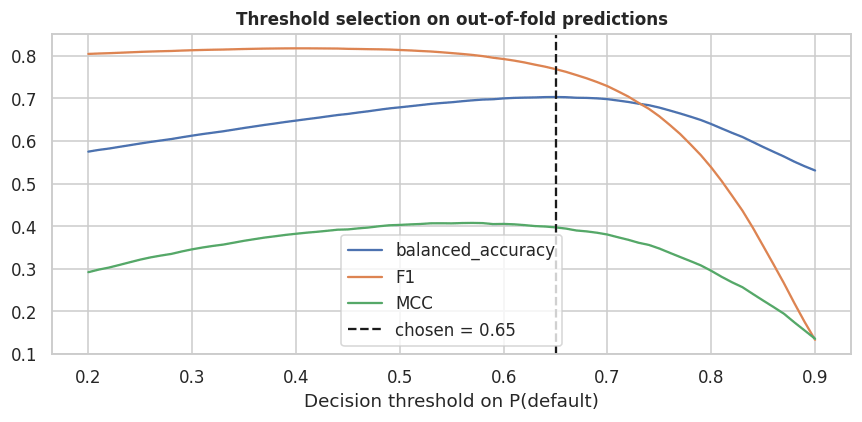

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score,
                             precision_score, recall_score, brier_score_loss)

oof = cross_val_predict(final_pipe, X_train, y_train, cv=cv5, method="predict_proba", n_jobs=1)[:, 1]
grid = np.linspace(0.20, 0.90, 71)
curves = pd.DataFrame({
    "threshold": grid,
    "balanced_accuracy": [balanced_accuracy_score(y_train, oof >= t) for t in grid],
    "F1": [f1_score(y_train, oof >= t) for t in grid],
    "MCC": [matthews_corrcoef(y_train, oof >= t) for t in grid],
})
THRESHOLD = float(grid[curves["balanced_accuracy"].values.argmax()])
print(f"Out-of-fold ROC-AUC on training data: {roc_auc_score(y_train, oof):.4f}")
print(f"Chosen threshold (max balanced accuracy): {THRESHOLD:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
for c in ["balanced_accuracy", "F1", "MCC"]:
    ax.plot(curves["threshold"], curves[c], label=c)
ax.axvline(THRESHOLD, color="k", ls="--", label=f"chosen = {THRESHOLD:.2f}")
ax.set_xlabel("Decision threshold on P(default)"); ax.legend(); ax.set_title("Threshold selection on out-of-fold predictions")
plt.tight_layout(); save_fig(fig, "09_threshold"); plt.show()

## 2.6 Final evaluation on the untouched test set
The champion is refitted on the whole training set and scored once on the 20% of loans that nobody has looked at. The other six baseline families are scored on the same loans purely for the comparison chart, since they were already ruled out by cross-validation.

In [ ]:
t0 = time.time()
final_pipe.fit(X_train, y_train)
p_test = final_pipe.predict_proba(X_test)[:, 1]
p_train = final_pipe.predict_proba(X_train)[:, 1]
pred_test = (p_test >= THRESHOLD).astype(int)
print(f"Champion fitted in {time.time() - t0:.0f}s")

def bootstrap_ci(y_true, score, n=1000, seed=SEED):
    r = np.random.default_rng(seed); y_true = np.asarray(y_true); n_obs = len(y_true)
    vals = [roc_auc_score(y_true[i], score[i]) for i in (r.integers(0, n_obs, n_obs) for _ in range(n))]
    return np.percentile(vals, [2.5, 97.5])

lo, hi = bootstrap_ci(y_test, p_test)
tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
test_metrics = pd.Series({
    "ROC-AUC": roc_auc_score(y_test, p_test), "ROC-AUC 95% CI low": lo, "ROC-AUC 95% CI high": hi,
    "PR-AUC": average_precision_score(y_test, p_test), "Accuracy": accuracy_score(y_test, pred_test),
    "Balanced accuracy": balanced_accuracy_score(y_test, pred_test),
    "Precision (default)": precision_score(y_test, pred_test), "Recall (default)": recall_score(y_test, pred_test),
    "Specificity (repaid)": tn / (tn + fp), "F1": f1_score(y_test, pred_test),
    "MCC": matthews_corrcoef(y_test, pred_test), "Brier score": brier_score_loss(y_test, p_test),
    "Train ROC-AUC (in-sample)": roc_auc_score(y_train, p_train),
})
display(test_metrics.to_frame(f"{champion_name}, threshold {THRESHOLD:.2f}"))

Champion fitted in 12s


,"XGBoost (tuned), threshold 0.65"
ROC-AUC,0.7807
ROC-AUC 95% CI low,0.7745
ROC-AUC 95% CI high,0.7869
PR-AUC,0.8452
Accuracy,0.7173
Balanced accuracy,0.7089
Precision (default),0.8042
Recall (default),0.7388
Specificity (repaid),0.6791
F1,0.7701


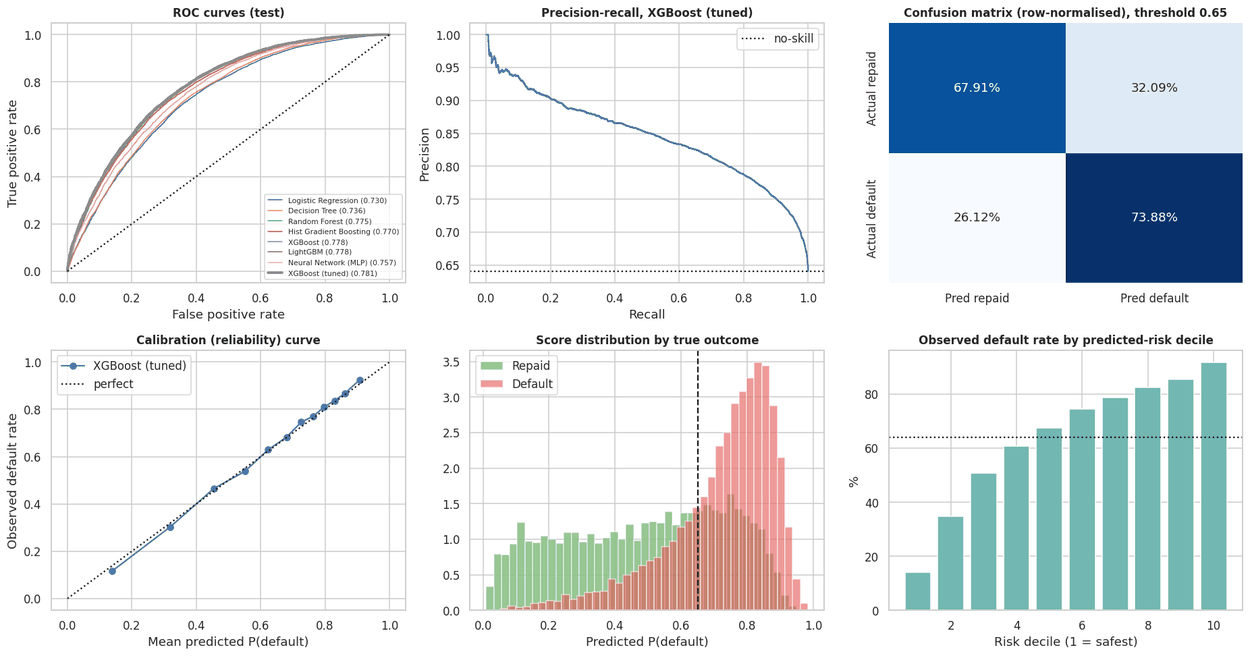

,Test ROC-AUC
XGBoost (tuned),0.7807
LightGBM,0.7781
XGBoost,0.7779
Random Forest,0.7746
Hist Gradient Boosting,0.7705
Neural Network (MLP),0.7569
Decision Tree,0.7360
Logistic Regression,0.7300


In [ ]:
from sklearn.calibration import calibration_curve

baseline_test = {}
for name, pipe in make_models().items():
    m = pipe.fit(X_train, y_train)
    baseline_test[name] = m.predict_proba(X_test)[:, 1]
baseline_test[champion_name] = p_test

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
ax = axes[0, 0]
for name, sc in baseline_test.items():
    f, t, _ = roc_curve(y_test, sc)
    ax.plot(f, t, lw=2.5 if name == champion_name else 1, label=f"{name} ({roc_auc_score(y_test, sc):.3f})")
ax.plot([0, 1], [0, 1], "k:"); ax.set_title("ROC curves (test)"); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.legend(fontsize=7)

ax = axes[0, 1]
pr, rc, _ = precision_recall_curve(y_test, p_test)
ax.plot(rc, pr, color="#4C78A8"); ax.axhline(y_test.mean(), color="k", ls=":", label="no-skill")
ax.set_title(f"Precision-recall, {champion_name}"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()

ax = axes[0, 2]
cm = confusion_matrix(y_test, pred_test, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Pred repaid", "Pred default"], yticklabels=["Actual repaid", "Actual default"])
ax.set_title(f"Confusion matrix (row-normalised), threshold {THRESHOLD:.2f}")

ax = axes[1, 0]
fr, mp = calibration_curve(y_test, p_test, n_bins=12, strategy="quantile")
ax.plot(mp, fr, marker="o", color="#4C78A8", label=champion_name); ax.plot([0, 1], [0, 1], "k:", label="perfect")
ax.set_title("Calibration (reliability) curve"); ax.set_xlabel("Mean predicted P(default)"); ax.set_ylabel("Observed default rate"); ax.legend()

ax = axes[1, 1]
for lab, colr, nm in [(0, "#54A24B", "Repaid"), (1, "#E45756", "Default")]:
    ax.hist(p_test[y_test.values == lab], bins=40, alpha=.6, color=colr, density=True, label=nm)
ax.axvline(THRESHOLD, color="k", ls="--"); ax.set_title("Score distribution by true outcome"); ax.set_xlabel("Predicted P(default)"); ax.legend()

ax = axes[1, 2]
dec = pd.qcut(p_test, 10, labels=False, duplicates="drop")
lift = pd.DataFrame({"decile": dec, "y": y_test.values}).groupby("decile")["y"].mean() * 100
ax.bar(lift.index + 1, lift.values, color="#72B7B2"); ax.axhline(y_test.mean() * 100, color="k", ls=":")
ax.set_title("Observed default rate by predicted-risk decile"); ax.set_xlabel("Risk decile (1 = safest)"); ax.set_ylabel("%")
plt.tight_layout(); save_fig(fig, "10_test_evaluation"); plt.show()

test_table = pd.Series({n: roc_auc_score(y_test, s) for n, s in baseline_test.items()}, name="Test ROC-AUC").sort_values(ascending=False)
display(test_table.to_frame())

**Test-set reading.** On 22,069 loans the champion reaches ROC-AUC 0.781 (95% interval 0.775 to 0.787), close to its cross-validated 0.772. In-sample AUC is 0.841, so the model clearly fits its training data better than new data, as boosted trees always do. The test figure is the honest one. At the chosen threshold it catches 73.9% of the defaulters (recall) and 80.4% of the loans it flags really do default (precision), but it also wrongly flags 32.1% of the good borrowers (specificity is 67.9%). The Brier score of 0.174 compares with 0.230 for a model that predicts the average default rate for everyone.

The decile chart is the most business-relevant picture. Moving from the safest tenth of applicants to the riskiest, the observed default rate rises from 14.0% to 91.7% (14.0, 34.8, 50.8, 60.7, 67.4, 74.6, 78.7, 82.5, 85.6, 91.7). The model ranks risk well even though its yes/no decisions are far from perfect.

## 2.7 Robustness: does the score survive drift and ablation?
Two stress tests that a random split cannot provide.

1. **Time-based validation.** Train only on loans issued up to 2018, test on loans from 2019 onwards. This mimics deployment, where the model always scores a future it has not seen.
2. **Ablation.** Remove one block of features at a time and refit, to see which parts the model genuinely relies on.

In [ ]:
LOANYEAR_CUT = 2018
tr_mask = meta_all["LoanYear"] <= LOANYEAR_CUT
Xt_tr, Xt_te = X_all[tr_mask], X_all[~tr_mask]
yt_tr, yt_te = y_all[tr_mask], y_all[~tr_mask]

def refit_score(drop=(), temporal=False):
    pipe = build_pipe(clone(final_pipe.named_steps["clf"]), drop=drop)
    if temporal:
        pipe.fit(Xt_tr, yt_tr); return roc_auc_score(yt_te, pipe.predict_proba(Xt_te)[:, 1])
    pipe.fit(X_train, y_train); return roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

robust = pd.DataFrame({
    "Setting": ["Random split (reference)", f"Time split: train <= {LOANYEAR_CUT}, test >= {LOANYEAR_CUT + 1}",
                "Ablation: without Interest", "Ablation: without the 5 engineered ratios",
                "Ablation: without Country"],
    "ROC-AUC": [refit_score(), refit_score(temporal=True), refit_score(("Interest",)),
                refit_score(tuple(lu.ENGINEERED)), refit_score(("Country",))],
})
robust["vs reference"] = robust["ROC-AUC"] - robust.loc[0, "ROC-AUC"]
print(f"Time-split sizes: train {len(Xt_tr):,} loans, test {len(Xt_te):,} loans")
display(robust)

Time-split sizes: train 64,873 loans, test 45,469 loans


,Setting,ROC-AUC,vs reference
0,Random split (reference),0.7807,0.0000
1,"Time split: train <= 2018, test >= 2019",0.7154,-0.0652
2,Ablation: without Interest,0.7788,-0.0019
3,Ablation: without the 5 engineered ratios,0.7810,0.0003
4,Ablation: without Country,0.7783,-0.0023


**What the stress tests show.** The time-based split is the sobering result. Trained on loans up to 2018 and tested on 2019 onward, ROC-AUC falls from 0.781 to 0.715. A random split mixes all years together, so it flatters the model; a lender would always be scoring a future the model has not seen. Default rates and the borrower mix change from year to year in this data (and 2020 brings the pandemic), which are plausible reasons, though this notebook does not isolate which matters most. The practical lesson is that any deployed version needs monitoring and regular retraining, and that 0.715 is the more cautious figure to quote for real-world use.

The ablations are reassuring on the points that matter. Dropping the interest rate costs only 0.002, so the model is not just echoing the lender's own pricing. Dropping Country costs 0.002, so the geography effect is carried by other features too. Dropping the five engineered ratios changes nothing (+0.0003). They did not add accuracy, which is worth saying plainly. They stay because they make explanations and the symbolic rules in 3.3 far easier to read.

---
# 3. Explainable AI: SHAP, LIME and neurosymbolic XAI

A model that ranks risk well is only half a product. A loan officer, a regulator and the applicant each need a different kind of answer.

| Method | Question it answers | Nature |
|---|---|---|
| **SHAP** | How much did each feature push *this* score up or down, and which features matter overall? | Exact, additive attribution for tree models |
| **LIME** | What does a simple local model say about this one applicant? | Sampling-based local approximation |
| **Neurosymbolic XAI** | Can the learned model be *translated into rules*, *checked against written credit knowledge* and *held to account* when it disagrees with that knowledge? | Learned (sub-symbolic) model plus symbolic rules |

The cell below gets the fitted champion ready for all three.

In [ ]:
import shap
from lime.lime_tabular import LimeTabularExplainer

prep = final_pipe.named_steps["prep"]
clf = final_pipe.named_steps["clf"]
assert "scale" not in final_pipe.named_steps, "explainers below assume an unscaled tree model"

feat_names = prep.get_feature_names_out().tolist()
def base_of(name):
    for c in lu.CATEGORICAL:
        if name.startswith(c + "_"):
            return c
    return name
BASE = pd.Series({n: base_of(n) for n in feat_names})

Xtr_t = pd.DataFrame(prep.transform(X_train), columns=feat_names, index=X_train.index)
Xte_t = pd.DataFrame(prep.transform(X_test), columns=feat_names, index=X_test.index)

N_SHAP = min(4000, len(Xte_t))
shap_pos = np.sort(rng.choice(len(Xte_t), size=N_SHAP, replace=False))
Xs = Xte_t.iloc[shap_pos]
Xs_raw = X_test.iloc[shap_pos]
p_s = p_test[shap_pos]
print(f"Champion: {champion_name} | explained sample: {N_SHAP:,} test applicants | {len(feat_names)} model columns "
      f"from {BASE.nunique()} original features")

Champion: XGBoost (tuned) | explained sample: 4,000 test applicants | 69 model columns from 26 original features


## 3.1 SHAP: global and local attribution
`TreeExplainer` computes Shapley values exactly for tree ensembles. For boosted models the values are in log-odds, and for every applicant `baseline + sum(SHAP values)` must equal the model's raw score. The cell checks that identity, which is the quickest way to catch a misconfigured explainer.

In [ ]:
explainer = shap.TreeExplainer(clf)
ex = explainer(Xs.values)
vals, base = ex.values, ex.base_values
if vals.ndim == 3:
    vals = vals[:, :, 1]
if np.ndim(base) == 2:
    base = base[:, 1]
base = np.broadcast_to(np.asarray(base, dtype=float), (len(Xs),))

is_boosted = type(clf).__name__ in ("XGBClassifier", "LGBMClassifier")
target = np.log(p_s / (1 - p_s)) if is_boosted else p_s
recon = base + vals.sum(axis=1)
add_err = float(np.abs(recon - target).max())
print(f"Scale of SHAP values: {'log-odds' if is_boosted else 'probability'}")
print(f"Additivity check, max |baseline + sum(SHAP) - model output| = {add_err:.2e}")
assert add_err < 0.05, "SHAP values do not add up to the model output"

expl = shap.Explanation(values=vals, base_values=base, data=Xs.values, feature_names=feat_names)

# one-hot columns folded back into their original feature (signed sum per applicant)
grouped = pd.DataFrame(vals, columns=feat_names).T.groupby(BASE).sum().T
grouped.index = Xs.index
importance = grouped.abs().mean().sort_values(ascending=False)
display(importance.head(12).rename("mean |SHAP| (log-odds)").to_frame())

Scale of SHAP values: log-odds
Additivity check, max |baseline + sum(SHAP) - model output| = 5.07e-06


,mean |SHAP| (log-odds)
LoanDuration,0.2944
CreditScoreEeMini,0.2462
Country,0.2343
Education,0.1592
PrevRepaymentRatio,0.1521
Interest,0.1444
HomeOwnershipType,0.1286
VerificationType,0.1015
Age,0.0951
ExistingLiabilities,0.0926


**Global importance.** Merged back to the 26 original features, the ranking is: loan term (0.294), the Estonian bureau score (0.246), country (0.234), education (0.159), the ratio of earlier repayments to earlier borrowing (0.152), interest (0.144) and home ownership (0.129). Two observations. First, the strongest drivers are the shape of the loan and the market the borrower lives in, more than classic affordability measures: `LiabToIncome` is 11th at 0.068 and `PaymentToIncome` is lower still. Second, because of the correlation note in 1.8, the three earlier-loan features probably deserve to be read as one group.

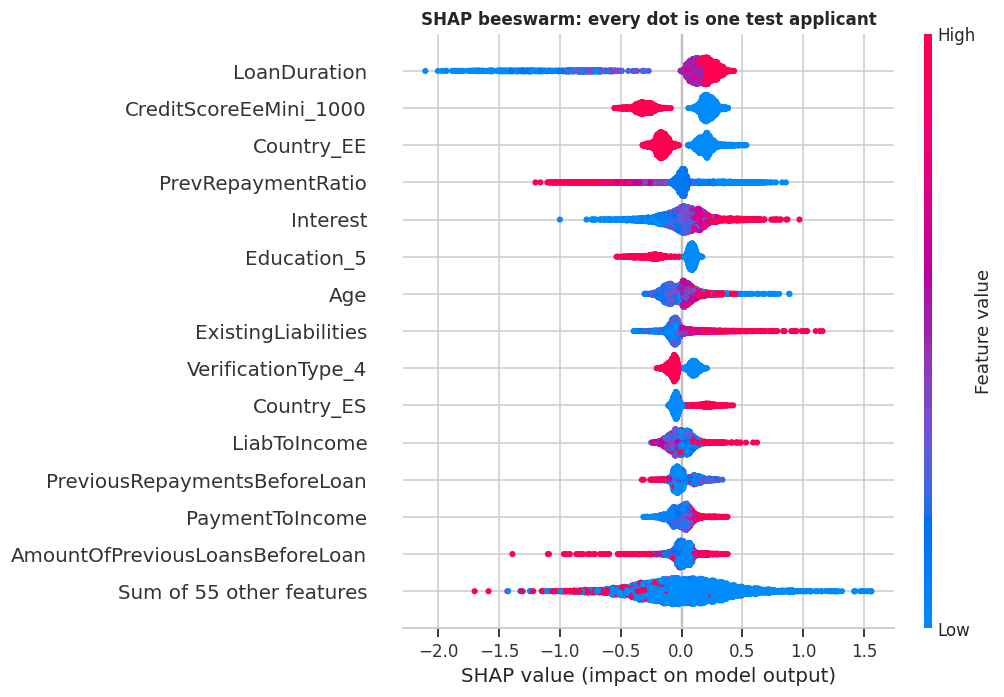

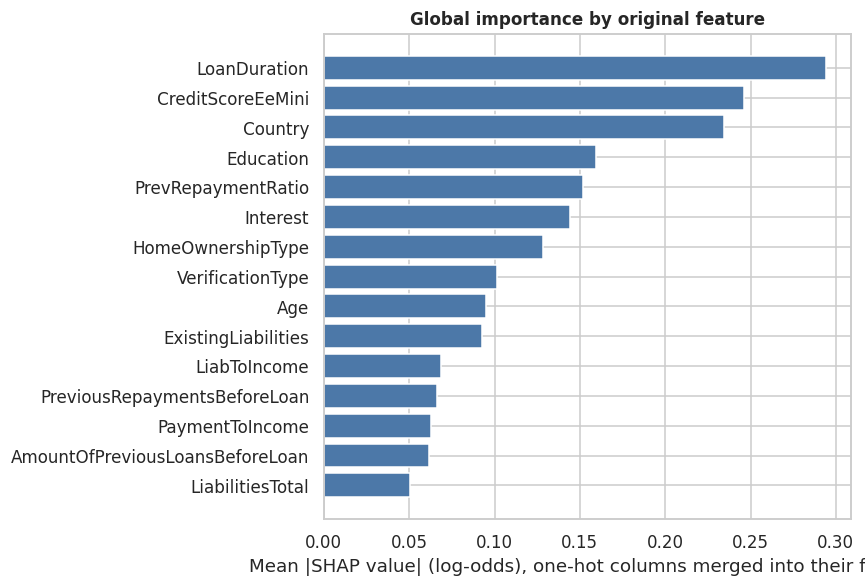

In [ ]:
shap.plots.beeswarm(expl, max_display=15, show=False)
fig = plt.gcf(); fig.set_size_inches(9.5, 6.5); plt.title("SHAP beeswarm: every dot is one test applicant")
plt.tight_layout(); save_fig(fig, "11_shap_beeswarm"); plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
top = importance.head(15)[::-1]
ax.barh(top.index, top.values, color="#4C78A8")
ax.set_xlabel("Mean |SHAP value| (log-odds), one-hot columns merged into their feature")
ax.set_title("Global importance by original feature")
plt.tight_layout(); save_fig(fig, "12_shap_importance"); plt.show()

**Reading the beeswarm.** Each row is a feature, each dot an applicant, colour is the feature's value and horizontal position is how far it pushed the score (right means higher default risk). Short loan terms (blue) push strongly to the left, down to about -2 in log-odds, while 60-month terms push mildly right. An Estonian bureau score of 1000 and living in Estonia both pull risk down, and Spain pushes it up. A high repayment ratio (red) pulls risk down hard. High interest and many existing liabilities push risk up, with the biggest pushes coming from a small number of extreme applicants. SHAP values here are in log-odds, which is why they can exceed 1 in size while the probability stays between 0 and 1.

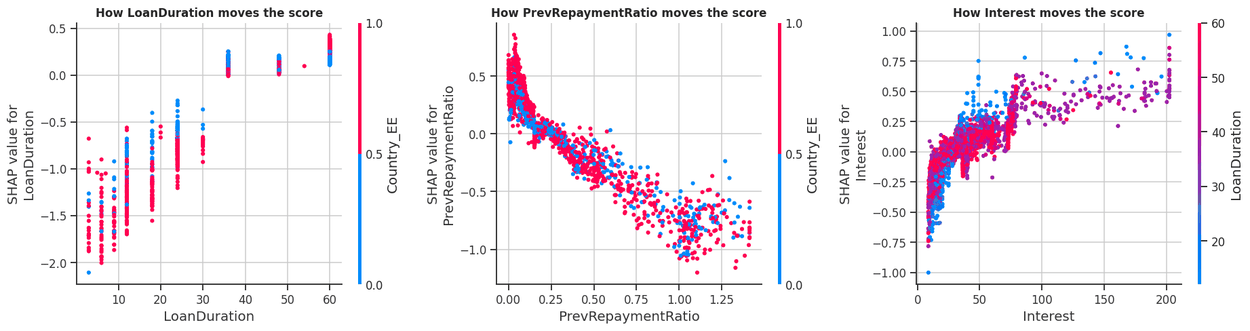

In [ ]:
top_numeric = [f for f in importance.index if f in lu.NUMERIC_ALL][:3]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, f in zip(axes, top_numeric):
    shap.dependence_plot(f, vals, Xs, feature_names=feat_names, ax=ax, show=False)
    ax.set_title(f"How {f} moves the score")
plt.tight_layout(); save_fig(fig, "13_shap_dependence"); plt.show()

**Reading the dependence plots.** Loan term rises in steps, with the sharpest jump between short loans and the 36-month mark, after which the curve is nearly flat. Interest raises risk steeply between roughly 10% and 50%, then flattens out beyond about 75%, so a 150% rate is not treated as three times as risky as a 50% rate. The repayment ratio is almost a straight downward line: borrowers who have already repaid a large share of what they borrowed before are the safest group. All three shapes are sensible, which is a good sign. The one unsettling point is that the shapes are not guaranteed to be monotone, and 3.3.5 measures how often that matters.

### Local explanations
Three applicants with very different stories: the one the model is most worried about, the one it trusts most, and one sitting right on the decision threshold. The bars show how each feature moved the score away from the average applicant. Values on the left of the plot are the preprocessed (clipped, imputed) inputs the model actually saw.

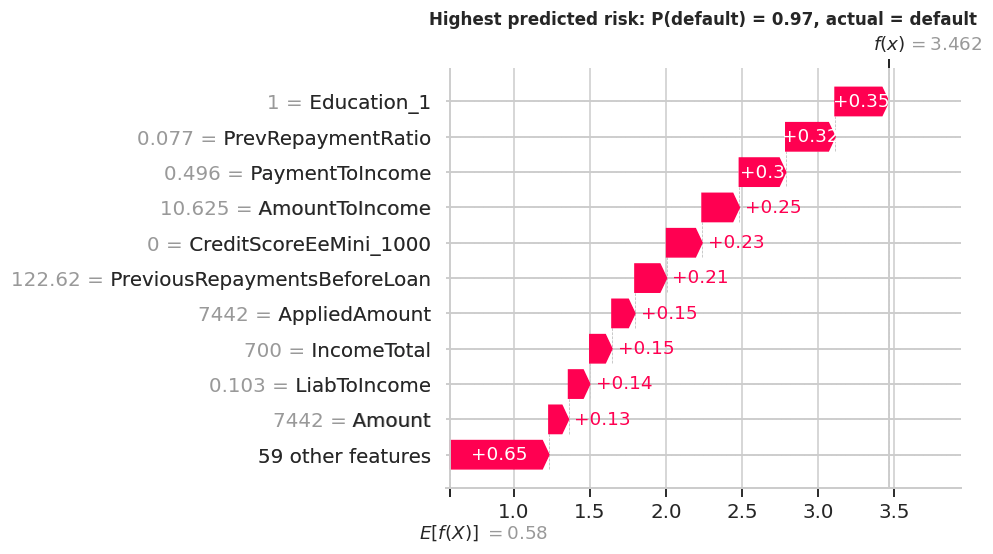

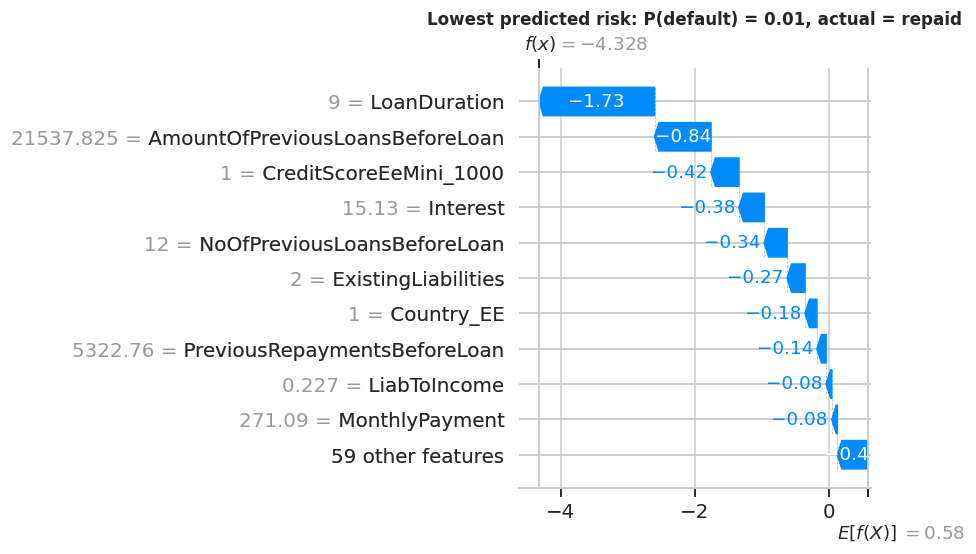

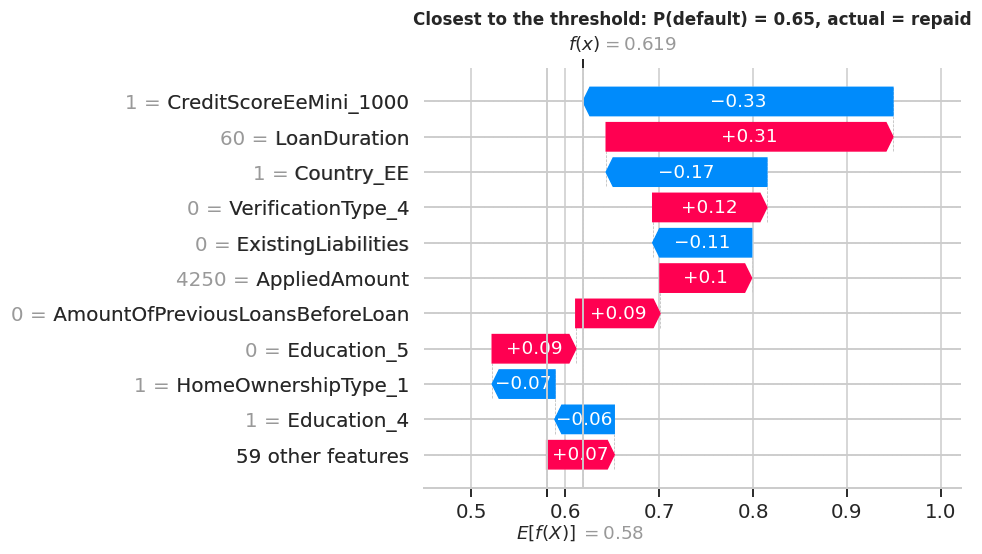

In [ ]:
cases = {
    "Highest predicted risk": int(np.argmax(p_s)),
    "Lowest predicted risk": int(np.argmin(p_s)),
    "Closest to the threshold": int(np.argmin(np.abs(p_s - THRESHOLD))),
}
for title, i in cases.items():
    shap.plots.waterfall(expl[i], max_display=11, show=False)
    fig = plt.gcf(); fig.set_size_inches(9, 5.2)
    plt.title(f"{title}: P(default) = {p_s[i]:.2f}, actual = {'default' if y_test.iloc[shap_pos[i]] else 'repaid'}")
    plt.tight_layout(); save_fig(fig, "14_shap_waterfall_" + title.split()[0].lower()); plt.show()

**How to read a waterfall.** Start at the grey baseline, which is the average applicant's score. Each bar moves the score up (red) or down (blue) by that feature's contribution, and the bars add up exactly to the applicant's final score. Because SHAP is additive, the sizes can be compared directly, and the same chart can be shown to a credit officer to justify a decision feature by feature.

## 3.2 LIME: local surrogate explanations
LIME perturbs one applicant thousands of times, asks the model what it would say, and fits a small weighted linear model around that point. It treats the model as a black box, so it is a useful independent check on SHAP.

One design decision matters here. LIME is run on the **original 26 applicant features** (the model's full pipeline is wrapped as the black box) and not on the 69 one-hot columns. Perturbing one-hot columns independently would create impossible applicants (living in two countries at once), and the explanation would then describe a world that does not exist. Working on the original features also makes LIME directly comparable with SHAP, which is merged to the same 26 features.

Two things are measured and not assumed: how well the local surrogate fits (`R²`) and whether LIME agrees with SHAP.

Black-box wrapper vs model, max abs difference on 200 applicants: 0.0


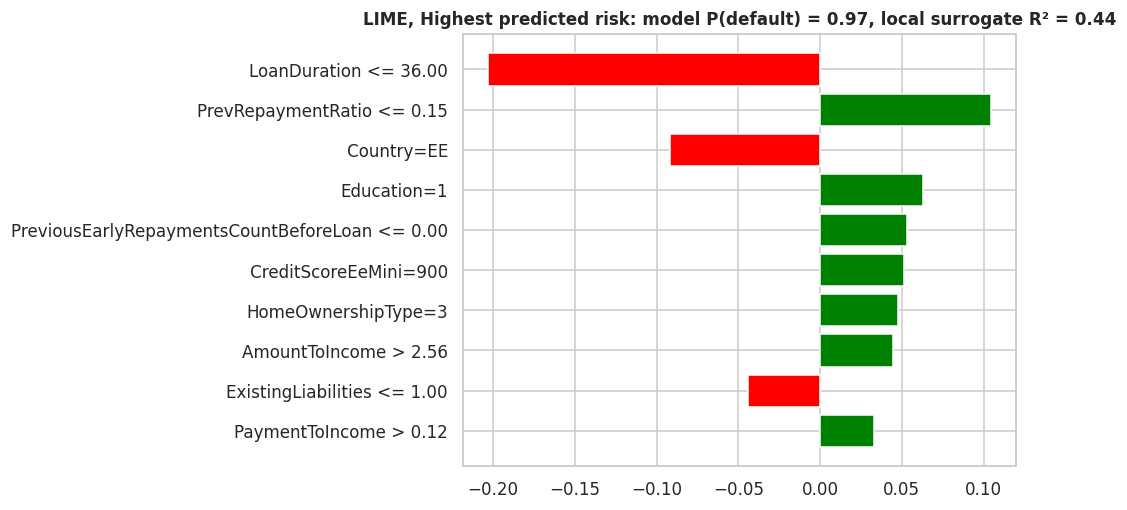

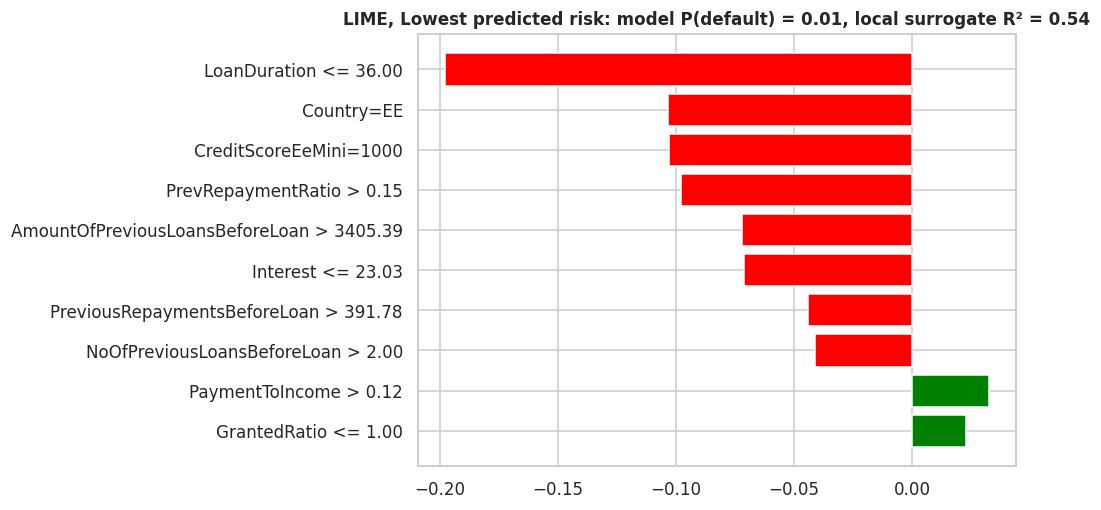

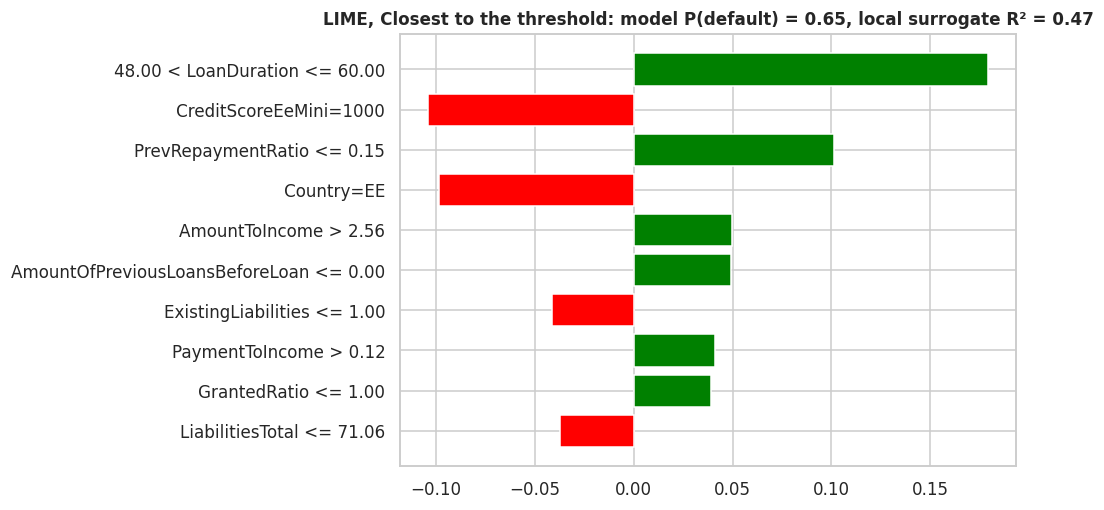

In [ ]:
lime_num, lime_cat = lu.NUMERIC_ALL, lu.CATEGORICAL
lime_cols = lime_num + lime_cat
lime_med = X_train[lime_num].median()
cat_levels = {c: sorted(X_all[c].unique().tolist()) for c in lime_cat}
cat_index = {c: {v: i for i, v in enumerate(levels)} for c, levels in cat_levels.items()}

def to_lime_matrix(df):
    num = df[lime_num].fillna(lime_med).to_numpy(dtype=float)
    cat = np.column_stack([df[c].map(cat_index[c]).to_numpy(dtype=float) for c in lime_cat])
    return np.hstack([num, cat])

def from_lime_matrix(M):
    df = pd.DataFrame(M[:, :len(lime_num)], columns=lime_num)
    for j, c in enumerate(lime_cat):
        df[c] = [cat_levels[c][int(round(v))] for v in M[:, len(lime_num) + j]]
    return df[lime_cols]

def lime_predict(M):
    p1 = final_pipe.predict_proba(from_lime_matrix(M))[:, 1]
    return np.column_stack([1 - p1, p1])

lime_train = to_lime_matrix(X_train.iloc[rng.choice(len(X_train), size=20000, replace=False)])
cat_idx = list(range(len(lime_num), len(lime_cols)))

def make_lime(seed):
    return LimeTabularExplainer(
        lime_train, feature_names=lime_cols, class_names=["Repaid", "Default"],
        categorical_features=cat_idx, categorical_names={len(lime_num) + j: cat_levels[c] for j, c in enumerate(lime_cat)},
        discretize_continuous=True, mode="classification", random_state=seed)

lime_a = make_lime(SEED)
Xs_lime = to_lime_matrix(Xs_raw)

# sanity: the black box must reproduce the model's own score on the filled-in applicants
check_back = lime_predict(Xs_lime[:200])[:, 1]
print("Black-box wrapper vs model, max abs difference on 200 applicants:", float(np.abs(check_back - p_s[:200]).max()))
assert np.abs(check_back - p_s[:200]).max() < 1e-4

for title, i in cases.items():
    e = lime_a.explain_instance(Xs_lime[i], lime_predict, num_features=10, num_samples=4000)
    f = e.as_pyplot_figure(label=1); f.set_size_inches(9.5, 4.8)
    plt.title(f"LIME, {title}: model P(default) = {p_s[i]:.2f}, local surrogate R² = {e.score:.2f}")
    plt.tight_layout(); save_fig(f, "15_lime_" + title.split()[0].lower()); plt.show()

### Do SHAP and LIME tell the same story? Is LIME stable?
For 40 test applicants we compare the five most influential features according to each method (Jaccard overlap, where 1.0 means identical sets), whether the *direction* of the shared features matches, and how much LIME changes when only its random seed changes. SHAP and LIME measure different things (log-odds contribution against the average applicant, versus a local probability slope), so perfect agreement is not expected. Broad agreement on which features matter is.

In [ ]:
N_CMP = 40
lime_b = make_lime(SEED + 1)

def lime_weights(explainer_obj, x_row):
    e = explainer_obj.explain_instance(x_row, lime_predict, num_features=len(lime_cols), num_samples=4000)
    return pd.Series({lime_cols[i]: wt for i, wt in e.as_map()[1]}), e.score

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

rows, r2s, stab = [], [], []
for j in range(N_CMP):
    s_vec = grouped.iloc[j]
    lw_a, r2 = lime_weights(lime_a, Xs_lime[j]); r2s.append(r2)
    top_s = s_vec.abs().sort_values(ascending=False).index[:5]
    top_l = lw_a.abs().sort_values(ascending=False).index[:5]
    shared = [f for f in top_s if f in top_l]
    sign_ok = np.mean([np.sign(s_vec[f]) == np.sign(lw_a[f]) for f in shared]) if shared else np.nan
    rows.append({"jaccard_top5": jaccard(top_s, top_l), "top1_in_other_top3": top_s[0] in list(lw_a.abs().sort_values(ascending=False).index[:3]),
                 "top1_same": top_s[0] == top_l[0], "sign_agree_on_shared": sign_ok})
    if j < 20:
        lw_b, _ = lime_weights(lime_b, Xs_lime[j])
        stab.append(jaccard(top_l, lw_b.abs().sort_values(ascending=False).index[:5]))

agree = pd.DataFrame(rows)
lime_summary = {
    "shap_vs_lime_top5_jaccard": agree["jaccard_top5"].mean(),
    "shap_vs_lime_top1_same": agree["top1_same"].mean(),
    "shap_top1_inside_lime_top3": agree["top1_in_other_top3"].mean(),
    "shap_vs_lime_sign_agreement": agree["sign_agree_on_shared"].mean(),
    "lime_local_r2_mean": float(np.mean(r2s)),
    "lime_seed_stability_top5_jaccard": float(np.mean(stab)),
}
display(pd.Series(lime_summary, name="value").to_frame())

,value
shap_vs_lime_top5_jaccard,0.5188
shap_vs_lime_top1_same,0.2000
shap_top1_inside_lime_top3,0.6500
shap_vs_lime_sign_agreement,0.9200
lime_local_r2_mean,0.4555
lime_seed_stability_top5_jaccard,0.8214


**What the comparison says.** The two methods agree on the *direction* of the effect for 92% of the features they share, and SHAP's single most important feature appears in LIME's top three for 65% of applicants. They name exactly the same top-1 feature only 20% of the time, and the top-5 sets overlap at 0.52 (Jaccard). That is a moderate agreement and it is what one would expect: SHAP and LIME measure different things, and LIME fits a straight line to a model full of thresholds, so its local R² averages only 0.46. LIME itself is reasonably repeatable (top-5 overlap of 0.82 when only the random seed changes).

Practical reading: SHAP is the primary tool because it is exact and deterministic. LIME is a useful sanity check on direction, but its exact ranking of features should not be treated as precise.

## 3.3 Neurosymbolic XAI
SHAP and LIME explain a model in *its own* vocabulary: numbers attached to columns. A credit officer thinks in rules ("high interest, long term, first-time borrower"), and a regulator wants to know whether the system respects what is already known about credit risk. Neurosymbolic XAI connects the two worlds. Here it is built in four moves that run in both directions between the learned model and written knowledge.

```
        SYMBOLIC                                      SUB-SYMBOLIC (learned)
  expert credit rules  ----(3.3.2 compare)---->   champion model + SHAP attribution
  weighted rule scorecard <---(3.3.4 distil)----   rules mined from the model (3.3.4)
  expert constraints   ----(3.3.5 verify)----->   perturbation tests on the model
        \__________ (3.3.6) agreement triage and applicant-level reasoning __________/
```

### 3.3.1 The symbolic knowledge base
Nine IF-THEN rules written the way an analyst would write them, each with the direction of effect an expert would expect. They are defined in `loan_utils.RULEBOOK` and evaluated on plain applicant fields, with no model involved.

In [ ]:
kb_tr = lu.symbolic_predicates(X_train)
kb_te = lu.symbolic_predicates(X_test)
kb_s = lu.symbolic_predicates(Xs_raw)

kb_rows = []
for r in lu.RULEBOOK:
    n = r["name"]; m = kb_tr[n] == 1
    kb_rows.append({"rule": n, "IF ...": r["text"], "expert expects": "raises risk" if r["expected"] > 0 else "lowers risk",
                    "applicants covered": m.mean(), "default rate if true": y_train[m].mean(),
                    "default rate if false": y_train[~m].mean()})
kb_table = pd.DataFrame(kb_rows).set_index("rule")
display(kb_table.style.format({"applicants covered": "{:.1%}", "default rate if true": "{:.1%}", "default rate if false": "{:.1%}"})
        .set_properties(subset=["IF ..."], **{"white-space": "pre-wrap", "text-align": "left"}))

,IF ...,expert expects,applicants covered,default rate if true,default rate if false
rule,,,,,
HighPaymentBurden,the new monthly instalment is at least 15% of monthly income,raises risk,15.7%,69.6%,63.1%
HighLiabilityLoad,existing monthly liabilities are at least 40% of monthly income,raises risk,35.8%,61.0%,65.8%
LargeLoanVsIncome,the loan is at least 3 times the monthly income,raises risk,18.6%,66.2%,63.6%
HighInterestRate,the interest rate is at least 40% (lender priced the applicant as risky),raises risk,31.0%,76.9%,58.3%
LongLoanTerm,the loan term is 48 months or longer,raises risk,54.6%,70.6%,56.2%
FirstTimeBorrower,the applicant is a new credit customer with no track record,raises risk,61.2%,66.9%,59.7%
ShortEmploymentTenure,the applicant is on a trial period or has under one year with the current employer,raises risk,19.1%,63.0%,64.3%
ProvenRepayer,the applicant has already repaid 1000 or more on earlier loans,lowers risk,14.8%,51.6%,66.2%
LowIncome,monthly income is below 800,raises risk,18.3%,58.5%,65.3%


**Reading the knowledge base.** Four rules separate the data cleanly: high interest (76.9% default when true against 58.3% when false), a long term (70.6% against 56.2%), a heavy payment burden (69.6% against 63.1%), and a proven repayment record, which lowers the rate from 66.2% to 51.6%. Others are weak or even point the wrong way: short employment tenure shows no effect (63.0% against 64.3%), and low income shows the *opposite* of what an analyst would expect (58.5% against 65.3%). The next two steps look into why.

### 3.3.2 Does the learned model respect the expert rules?
A rule can be checked against two things: what the raw data say (default rate when the rule is true minus when it is false), and what the *model* does (average SHAP contribution of the rule's feature when the rule is true minus when it is false). A mismatch is not automatically an error. It is a flag that either the expert prior or the data need a second look, and that is exactly the kind of finding a risk committee should see.

In [ ]:
align_rows = []
for r in lu.RULEBOOK:
    n = r["name"]; m = kb_tr[n] == 1
    emp = y_train[m].mean() - y_train[~m].mean()
    ms = kb_s[n] == 1
    feat_cols = [f for f in r["features"] if f in grouped.columns]
    shap_vec = grouped[feat_cols].sum(axis=1)
    sh = shap_vec[ms.values].mean() - shap_vec[~ms.values].mean() if ms.any() and (~ms).any() else np.nan
    emp_ok, sh_ok = np.sign(emp) == r["expected"], np.sign(sh) == r["expected"]
    if emp_ok and sh_ok:            verdict = "aligned"
    elif (not emp_ok) and (not sh_ok): verdict = "CONFLICT: data and model both contradict the expert"
    elif emp_ok and (not sh_ok):    verdict = "CONFLICT: model contradicts expert and data"
    else:                           verdict = "CONFLICT: data contradicts expert, model follows expert"
    align_rows.append({"rule": n, "expert": "+" if r["expected"] > 0 else "-", "raw data effect (default-rate gap)": emp,
                       "model effect (mean SHAP gap)": sh, "verdict": verdict})
alignment = pd.DataFrame(align_rows).set_index("rule")
display(alignment.style.format({"raw data effect (default-rate gap)": "{:+.3f}", "model effect (mean SHAP gap)": "{:+.3f}"}))
print(f"Rules fully aligned: {(alignment['verdict'] == 'aligned').sum()} of {len(alignment)}")

,expert,raw data effect (default-rate gap),model effect (mean SHAP gap),verdict
rule,,,,
HighPaymentBurden,+,+0.066,+0.122,aligned
HighLiabilityLoad,+,-0.048,-0.060,CONFLICT: data and model both contradict the expert
LargeLoanVsIncome,+,+0.026,+0.070,aligned
HighInterestRate,+,+0.186,+0.258,aligned
LongLoanTerm,+,+0.144,+0.451,aligned
FirstTimeBorrower,+,+0.072,+0.010,aligned
ShortEmploymentTenure,+,-0.013,+0.003,"CONFLICT: data contradicts expert, model follows expert"
ProvenRepayer,-,-0.146,+0.032,CONFLICT: model contradicts expert and data
LowIncome,+,-0.069,+0.036,"CONFLICT: data contradicts expert, model follows expert"


Rules fully aligned: 5 of 9


**Reading the alignment table.** Five of nine rules are fully aligned (expert, data and model all agree). The four conflicts are of different kinds, and this matters more than the count:

* **HighLiabilityLoad:** data and model both say high liabilities go with *lower* default. The expert prior and the evidence disagree. This is the one that needs a risk-committee discussion.
* **ProvenRepayer:** the data back the expert strongly (-0.146), but the model's average contribution for this rule's feature moves the *wrong* way (+0.032). This is a genuine model weakness, and it is the one the constrained model in 3.3.5b repairs.
* **LowIncome and ShortEmploymentTenure:** the data contradict the expert, while the model happens to follow the expert. Section below explains why the data are misleading for LowIncome.

The SHAP gap compares only the rule's own feature, so it ignores interactions, and should be read as a rough indicator.

Several expert rules are contradicted by the raw data. Before blaming the expert, a classic trap is worth ruling out: **Simpson's paradox**, where a pooled trend reverses once you look inside each country (Spain and Finland have high default rates and may also differ in how liabilities or income are reported). The table repeats the default-rate gap *within* each country.

In [ ]:
ctr_train = meta_train["Country"]
strat = {}
for c in ["EE", "ES", "FI"]:
    mc = (ctr_train == c).values
    strat[c] = {r["name"]: (y_train[mc & (kb_tr[r["name"]] == 1).values].mean() - y_train[mc & (kb_tr[r["name"]] == 0).values].mean())
                for r in lu.RULEBOOK}
strat = pd.DataFrame(strat)
strat.insert(0, "pooled", alignment["raw data effect (default-rate gap)"])
strat.insert(0, "expert", ["+" if r["expected"] > 0 else "-" for r in lu.RULEBOOK])
strat["holds in all 3 countries"] = [
    all(np.sign(strat.loc[n, c]) == (1 if strat.loc[n, "expert"] == "+" else -1) for c in ["EE", "ES", "FI"]) for n in strat.index]
display(strat.style.format({"pooled": "{:+.3f}", "EE": "{:+.3f}", "ES": "{:+.3f}", "FI": "{:+.3f}"}))

,expert,pooled,EE,ES,FI,holds in all 3 countries
HighPaymentBurden,+,+0.066,+0.113,+0.013,+0.051,True
HighLiabilityLoad,+,-0.048,-0.027,-0.063,+0.008,False
LargeLoanVsIncome,+,+0.026,+0.106,+0.037,+0.026,True
HighInterestRate,+,+0.186,+0.113,+0.014,+0.055,True
LongLoanTerm,+,+0.144,+0.181,+0.043,+0.024,True
FirstTimeBorrower,+,+0.072,-0.000,+0.099,-0.024,False
ShortEmploymentTenure,+,-0.013,+0.033,+0.008,-0.021,False
ProvenRepayer,-,-0.146,-0.104,-0.206,-0.058,True
LowIncome,+,-0.069,+0.044,+0.042,-0.043,False


**A Simpson's paradox, partly.** Pooled across countries, low income appears to *lower* default (-0.069). Inside Estonia (+0.044) and Spain (+0.042) it raises default, as the expert expected. Only Finland (-0.043) goes the other way. Countries differ in both income levels and default rates, and mixing them reverses the sign. The expert was right in two of three markets, and the pooled table was misleading. The same check explains part of the first-time-borrower rule: strongly positive in Spain (+0.099), flat in Estonia, slightly negative in Finland. The four rules that hold everywhere (payment burden, loan size against income, interest, loan term) plus ProvenRepayer are the solid core. HighLiabilityLoad stays contradicted in two countries and is not explained by country mix.

### 3.3.3 Symbolic scorecard: weighted rules (Markov-logic style)
Give each rule a learned weight and combine them: `P(default) = sigmoid(bias + sum of weights of the rules that fire)`. This is the same shape as a Markov logic network, and every weight is a log-odds contribution an analyst can read. It uses **only** the nine rules and no hidden features, which makes it the purely symbolic counterpart to the learned model. We fit it on training data and pick its threshold the same way as before.

In [ ]:
scorecard = LogisticRegression(C=1.0, max_iter=1000).fit(kb_tr, y_train)
p_sym_tr = scorecard.predict_proba(kb_tr)[:, 1]
p_sym_te = scorecard.predict_proba(kb_te)[:, 1]
fpr_, tpr_, thr_ = roc_curve(y_train, p_sym_tr)
THR_SYM = float(thr_[np.argmax(tpr_ - fpr_)])

weights = pd.DataFrame({
    "weight (log-odds)": scorecard.coef_[0],
    "odds multiplier": np.exp(scorecard.coef_[0]),
    "expert expects": [("+" if r["expected"] > 0 else "-") for r in lu.RULEBOOK],
}, index=kb_tr.columns)
weights["sign matches expert"] = np.sign(weights["weight (log-odds)"]) == weights["expert expects"].map({"+": 1, "-": -1})
display(weights.sort_values("weight (log-odds)", ascending=False))
print(f"Bias (log-odds when no rule fires): {scorecard.intercept_[0]:+.3f}")
print(f"Scorecard test ROC-AUC = {roc_auc_score(y_test, p_sym_te):.4f}   vs   champion test ROC-AUC = {roc_auc_score(y_test, p_test):.4f}")
print(f"Scorecard threshold = {THR_SYM:.3f}")

,weight (log-odds),odds multiplier,expert expects,sign matches expert
HighInterestRate,0.7395,2.0950,+,True
LongLoanTerm,0.5339,1.7055,+,True
HighPaymentBurden,0.2134,1.2379,+,True
LargeLoanVsIncome,0.0387,1.0395,+,True
HighLiabilityLoad,-0.0243,0.9759,+,False
ShortEmploymentTenure,-0.0325,0.9681,+,False
FirstTimeBorrower,-0.0988,0.9059,+,False
LowIncome,-0.1366,0.8723,+,False
ProvenRepayer,-0.5285,0.5895,-,True


Bias (log-odds when no rule fires): +0.235
Scorecard test ROC-AUC = 0.6473   vs   champion test ROC-AUC = 0.7807
Scorecard threshold = 0.646


**Reading the scorecard.** Every weight is a log-odds contribution an analyst can read: a high interest rate multiplies the odds of default by 2.10, a long term by 1.71, a proven repayment record by 0.59. Four weights have the opposite sign from what the expert expected, but all four are small (0.14 or less in size) and fitted jointly, so a rule can turn negative simply because another rule that overlaps with it already explains the effect (first-time borrowers are, almost by definition, people without a proven repayment record).

The purely symbolic scorecard reaches ROC-AUC 0.647 against 0.781 for the champion. Nine yes/no rules cannot capture country, the bureau score, education and the fine detail in continuous values. That gap is the reason the champion exists, and the reason the neurosymbolic idea here is to *connect* the two, not replace one by the other.

### 3.3.4 Neural-to-symbolic: mining readable rules from the champion
Now the other direction. We ask: *what short list of IF-THEN rules reproduces what the champion does?* A shallow decision tree is trained to copy the champion's **decisions** (not the true labels) on training applicants. The symbolic vocabulary is the nine expert rules plus automatic yes/no tests built from the champion's most important features (quartile cut-points of numeric features and the common categories of categorical ones).

Success is measured by **fidelity**: how often the rules give the same decision as the champion on test applicants they have never seen. Depth is capped at 4 (at most 16 rules) because a rule list nobody can read is no explanation at all.

In [ ]:
top_num = [f for f in importance.index if f in lu.NUMERIC_ALL][:6]
top_cat = [f for f in importance.index if f in lu.CATEGORICAL][:3]

atom_specs = []
for f in top_num:
    for q in sorted(set(np.round(X_train[f].quantile([.25, .5, .75]).values, 4))):
        atom_specs.append(("num", f, float(q)))
for f in top_cat:
    freq = X_train[f].value_counts(normalize=True)
    for v in freq[freq >= 0.05].index[:4]:
        atom_specs.append(("cat", f, v))

def build_atoms(Xe):
    cols = {r["name"]: r["fn"](Xe).astype(int) for r in lu.RULEBOOK}
    for kind, f, v in atom_specs:
        if kind == "num":
            cols[f"{f} >= {v:g}"] = (Xe[f] >= v).astype(int)
        else:
            cols[f"{f} = {v}"] = (Xe[f] == v).astype(int)
    return pd.DataFrame(cols, index=Xe.index)

At_tr, At_te = build_atoms(X_train), build_atoms(X_test)
keep = [c for c in At_tr.columns if 0.02 <= At_tr[c].mean() <= 0.98]
At_tr, At_te = At_tr[keep], At_te[keep]
bb_tr = (p_train >= THRESHOLD).astype(int)
bb_te = (p_test >= THRESHOLD).astype(int)
print(f"Symbolic vocabulary: {At_tr.shape[1]} yes/no tests ({len(lu.RULEBOOK)} expert rules + {At_tr.shape[1] - len(lu.RULEBOOK)} mined tests)")

sweep = []
for d in range(1, 8):
    t_ = DecisionTreeClassifier(max_depth=d, min_samples_leaf=300, random_state=SEED).fit(At_tr, bb_tr)
    sweep.append({"max depth": d, "rules (leaves)": t_.get_n_leaves(),
                  "fidelity on train": (t_.predict(At_tr) == bb_tr).mean(), "fidelity on test": (t_.predict(At_te) == bb_te).mean()})
sweep = pd.DataFrame(sweep).set_index("max depth")
display(sweep.style.format({"fidelity on train": "{:.1%}", "fidelity on test": "{:.1%}"}))

Symbolic vocabulary: 36 yes/no tests (9 expert rules + 27 mined tests)


,rules (leaves),fidelity on train,fidelity on test
max depth,,,
1,2,72.7%,73.3%
2,4,72.9%,73.6%
3,8,76.3%,76.9%
4,14,78.1%,78.7%
5,26,80.2%,80.8%
6,44,80.7%,81.4%
7,64,81.0%,81.8%


In [ ]:
RULE_DEPTH = 4
surrogate = DecisionTreeClassifier(max_depth=RULE_DEPTH, min_samples_leaf=300, random_state=SEED).fit(At_tr, bb_tr)
leaf_te = surrogate.apply(At_te.values)
atom_names = At_tr.columns.tolist()
t_ = surrogate.tree_
rule_rows = []

def walk(node, conds):
    if t_.children_left[node] == -1:
        cls = int(np.argmax(t_.value[node][0]))
        m = leaf_te == node
        rule_rows.append({
            "IF": " AND ".join(conds) if conds else "(always)", "THEN": "FLAG" if cls == 1 else "PASS",
            "test applicants %": m.mean() * 100, "champion mean P(default)": p_test[m].mean(),
            "observed default rate": y_test.values[m].mean(),
            "champion agrees %": (bb_te[m] == cls).mean() * 100})
        return
    name = atom_names[t_.feature[node]]
    walk(t_.children_left[node], conds + [f"NOT [{name}]"])
    walk(t_.children_right[node], conds + [f"[{name}]"])
walk(0, [])

rules_df = pd.DataFrame(rule_rows).sort_values("test applicants %", ascending=False).reset_index(drop=True)
rules_df.index = [f"R{i + 1}" for i in rules_df.index]
fidelity_test = (surrogate.predict(At_te) == bb_te).mean()
surrogate_auc_true = roc_auc_score(y_test, surrogate.predict_proba(At_te)[:, 1])
print(f"{len(rules_df)} rules | fidelity to champion on unseen test applicants: {fidelity_test:.1%} | "
      f"rule-list ROC-AUC against true outcomes: {surrogate_auc_true:.3f} (champion {roc_auc_score(y_test, p_test):.3f})\n")
pd.set_option("display.max_colwidth", 140)
display(rules_df.style.format({"test applicants %": "{:.1f}", "champion mean P(default)": "{:.2f}",
                               "observed default rate": "{:.2f}", "champion agrees %": "{:.1f}"})
        .set_properties(subset=["IF"], **{"white-space": "pre-wrap", "text-align": "left"}))

14 rules | fidelity to champion on unseen test applicants: 78.7% | rule-list ROC-AUC against true outcomes: 0.702 (champion 0.781)



,IF,THEN,test applicants %,champion mean P(default),observed default rate,champion agrees %
R1,[Country = EE] AND [LoanDuration >= 36] AND [CreditScoreEeMini = 1000] AND NOT [Education = 5],PASS,25.1,0.60,0.61,57.1
R2,NOT [Country = EE] AND NOT [PrevRepaymentRatio >= 0.4422] AND [Interest >= 47.44] AND [LoanDuration >= 36],FLAG,21.3,0.80,0.81,95.0
R3,NOT [Country = EE] AND NOT [PrevRepaymentRatio >= 0.4422] AND NOT [Interest >= 47.44] AND [LoanDuration >= 36],FLAG,19.8,0.75,0.76,81.8
R4,[Country = EE] AND [LoanDuration >= 36] AND NOT [CreditScoreEeMini = 1000] AND NOT [CreditScoreEeMini = Missing],FLAG,9.3,0.72,0.74,74.3
R5,[Country = EE] AND NOT [LoanDuration >= 36] AND NOT [HighInterestRate] AND NOT [Interest >= 32.6],PASS,8.1,0.20,0.18,99.0
R6,[Country = EE] AND [LoanDuration >= 36] AND [CreditScoreEeMini = 1000] AND [Education = 5],PASS,6.1,0.43,0.41,84.7
R7,[Country = EE] AND NOT [LoanDuration >= 36] AND NOT [HighInterestRate] AND [Interest >= 32.6],PASS,1.7,0.35,0.40,96.5
R8,NOT [Country = EE] AND [PrevRepaymentRatio >= 0.4422] AND [ExistingLiabilities >= 1] AND [Age >= 39],FLAG,1.6,0.68,0.67,65.4
R9,NOT [Country = EE] AND NOT [PrevRepaymentRatio >= 0.4422] AND NOT [Interest >= 47.44] AND NOT [LoanDuration >= 36],PASS,1.6,0.59,0.63,53.2
R10,[Country = EE] AND [LoanDuration >= 36] AND NOT [CreditScoreEeMini = 1000] AND [CreditScoreEeMini = Missing],PASS,1.5,0.45,0.46,92.8


**Reading the mined rules.** With four levels of questions (14 rules) the list reproduces the champion's decision for 78.7% of unseen applicants. Always saying "FLAG" would already match 58.9%, so the rules add real information. Going deeper buys little: seven levels need 64 rules and reach only 81.8%, so we stop at four, where a person can still read the whole list. The rules recover what SHAP showed. The first question is Estonia against elsewhere, then loan term and the Estonian bureau score for Estonian applicants, and interest rate and repayment history elsewhere. Rule R2 (outside Estonia, interest 47% or above, little previous repayment, long term) covers 21.3% of applicants and the champion agrees on 95.0% of them.

One thing to be careful about: FLAG and PASS are decisions at the statistical threshold of 0.65, not verdicts about safety. Rule R1 says PASS for 25.1% of applicants, but their observed default rate is still 61%, because 0.65 sits above the average default rate of the population. The champion agrees with R1 only 57.1% of the time, so it is the least clean region. The rule list reaches ROC-AUC 0.702 against true outcomes, compared with the champion's 0.781.

### 3.3.5 Symbolic-to-neural: do the expert constraints hold inside the model?
Rules about *direction* can be tested directly. If an applicant's interest rate goes up by five points and nothing else changes, an analyst expects the model's default risk **not to fall**. We apply a controlled change to every test applicant's raw fields, rebuild the engineered ratios from scratch (so nothing becomes internally inconsistent), and count how often the model moves the wrong way by more than half a percentage point.

In [ ]:
raw_test = model_df.loc[X_test.index, lu.RAW_INPUT_COLUMNS].copy()
EPS = 0.005

CONSTRAINTS = [
    ("Interest +5 points", +1, lambda r: r.assign(Interest=r["Interest"] + 5),
     "higher interest should not lower risk"),
    ("Loan term +6 months (max 60)", +1, lambda r: r.assign(LoanDuration=np.minimum(r["LoanDuration"] + 6, 60)),
     "a longer exposure should not lower risk"),
    ("Monthly income +20%", -1, lambda r: r.assign(IncomeTotal=r["IncomeTotal"] * 1.2),
     "more income should not raise risk"),
    ("Monthly liabilities +20%", +1, lambda r: r.assign(LiabilitiesTotal=r["LiabilitiesTotal"] * 1.2),
     "more existing debt should not lower risk"),
    ("Earlier repayments +500", -1, lambda r: r.assign(PreviousRepaymentsBeforeLoan=r["PreviousRepaymentsBeforeLoan"].fillna(0) + 500),
     "a better repayment record should not raise risk"),
]

def check_constraints(model):
    base_p = model.predict_proba(X_test)[:, 1]
    rows, viol = [], {}
    for name, sign, fn, why in CONSTRAINTS:
        d = model.predict_proba(lu.engineer_features(fn(raw_test)))[:, 1] - base_p
        v = (d * sign) < -EPS
        viol[name] = v
        rows.append({"constraint": name, "expected rule": why, "mean change in P(default)": d.mean(), "applicants violating": v.mean()})
    return pd.DataFrame(rows).set_index("constraint"), pd.DataFrame(viol, index=X_test.index)

con_df, viol_df = check_constraints(final_pipe)
n_viol = viol_df.sum(axis=1).values
display(con_df.style.format({"mean change in P(default)": "{:+.4f}", "applicants violating": "{:.1%}"}))

acc_by_viol = pd.DataFrame({"violations": np.minimum(n_viol, 3), "correct": (pred_test == y_test.values)}).groupby("violations")["correct"].agg(["size", "mean"])
acc_by_viol.index = [{0: "0", 1: "1", 2: "2", 3: "3 or more"}[i] for i in acc_by_viol.index]
acc_by_viol.columns = ["applicants", "champion accuracy"]
note("**Champion accuracy against how many expert constraints it violates for the same applicant:**")
display(acc_by_viol.style.format({"champion accuracy": "{:.1%}"}))

,expected rule,mean change in P(default),applicants violating
constraint,,,
Interest +5 points,higher interest should not lower risk,+0.0149,18.3%
Loan term +6 months (max 60),a longer exposure should not lower risk,+0.0058,5.8%
Monthly income +20%,more income should not raise risk,-0.0064,31.2%
Monthly liabilities +20%,more existing debt should not lower risk,-0.0012,32.8%
Earlier repayments +500,a better repayment record should not raise risk,-0.0083,42.9%


**Champion accuracy against how many expert constraints it violates for the same applicant:**

,applicants,champion accuracy
0,5231,76.1%
1,8004,72.1%
2,6085,69.2%
3 or more,2749,68.0%


**Reading the constraint test.** The champion breaks the expert direction for a lot of applicants: a five-point higher interest rate lowers predicted risk for 18.3% of them, an extra 20% of income raises it for 31.2%, an extra 20% of liabilities lowers it for 32.8%, and an extra 500 of earlier repayments raises it for 42.9%. These are not bugs in the strict sense. A tree model has no built-in idea that more is worse, and each of these checks moves several engineered ratios at once. They are still flags, and they matter, because accuracy drops as violations pile up: 76.1% for applicants with none, 68.0% for applicants with three or more. That is a correlation (applicants in unusual corners of the feature space are harder), not proof that violations cause errors.

### 3.3.5b Injecting the knowledge: a monotone-constrained model
Finding a violation is useful. Removing it is better. Gradient boosting libraries let us *tell the model* that risk may not fall when interest rises, and so on (monotone constraints). That is symbolic knowledge flowing into the learner instead of just being checked against it.

Only constraints on which **the expert and the raw data agree** are enforced: interest rate, loan term, payment burden and earlier repayments (see 3.3.2). The income and liability rules are *not* enforced, because the data contradict them, and forcing an expert prior against the evidence would cost accuracy and could hide a real pattern. Those two stay on the list for a risk committee to decide.

In [ ]:
MONO = {"Interest": +1, "LoanDuration": +1, "PaymentToIncome": +1, "PreviousRepaymentsBeforeLoan": -1, "PrevRepaymentRatio": -1}
mono_vec = tuple(MONO.get(n, 0) for n in feat_names)
assert base_name(champion_name) in ("XGBoost", "LightGBM"), "monotone constraints are set up for XGBoost or LightGBM"
mono_pipe = clone(final_pipe).set_params(clf__monotone_constraints=mono_vec)
mono_pipe.fit(X_train, y_train)

p_mono = mono_pipe.predict_proba(X_test)[:, 1]
con_mono, viol_mono = check_constraints(mono_pipe)
cmp_mono = pd.DataFrame({
    "violations, champion": con_df["applicants violating"],
    "violations, constrained": con_mono["applicants violating"],
    "enforced?": ["yes" if n in ("Interest +5 points", "Loan term +6 months (max 60)", "Earlier repayments +500") else "no (data disagree)" for n in con_df.index],
})
display(cmp_mono.style.format({"violations, champion": "{:.1%}", "violations, constrained": "{:.1%}"}))

mono_summary = pd.DataFrame({
    "ROC-AUC": [roc_auc_score(y_test, p_test), roc_auc_score(y_test, p_mono)],
    "Balanced accuracy @ same threshold": [balanced_accuracy_score(y_test, p_test >= THRESHOLD), balanced_accuracy_score(y_test, p_mono >= THRESHOLD)],
    "Brier": [brier_score_loss(y_test, p_test), brier_score_loss(y_test, p_mono)],
}, index=["Champion (unconstrained)", "Knowledge-constrained variant"])
display(mono_summary)
print(f"Accuracy cost of the knowledge constraints: {roc_auc_score(y_test, p_test) - roc_auc_score(y_test, p_mono):+.4f} ROC-AUC")

,"violations, champion","violations, constrained",enforced?
constraint,,,
Interest +5 points,18.3%,0.0%,yes
Loan term +6 months (max 60),5.8%,0.0%,yes
Monthly income +20%,31.2%,30.3%,no (data disagree)
Monthly liabilities +20%,32.8%,32.0%,no (data disagree)
Earlier repayments +500,42.9%,2.4%,yes


,ROC-AUC,Balanced accuracy @ same threshold,Brier
Champion (unconstrained),0.7807,0.7089,0.1744
Knowledge-constrained variant,0.7763,0.7035,0.1760


Accuracy cost of the knowledge constraints: +0.0044 ROC-AUC


**What the knowledge injection achieved.** On the three constraints the data support, violations drop from 18.3%, 5.8% and 42.9% to 0.0%, 0.0% and 2.4% (the last one is not exactly zero because missing repayment history is imputed by a median, which is not a monotone step). The two constraints that were deliberately *not* enforced barely moved (31.2% to 30.3%, and 32.8% to 32.0%), which shows the monotone setting is doing exactly and only what we asked. The price is 0.0044 ROC-AUC (0.7807 to 0.7763), which is smaller than the width of the champion's own test interval (about 0.012 in total). A model that is slightly less accurate but never contradicts basic credit logic is a strong candidate for production, and the decision is left to the team. Both versions are saved.

### 3.3.6 Neural and symbolic reasoning side by side: when can the rules be offered as the reason?
For every test applicant we now have two independent opinions: the champion (learned from 20+ features) and the scorecard (nine written rules). When they agree, the written rules are a safe thing to show a loan officer or an applicant as the reason. When they disagree, the rules would tell the opposite story from the model, so the case is routed to a human credit officer instead.

The honest question is whether this agreement check is also a good *accuracy* filter. It is compared with the obvious alternative: sending the same number of cases to review, picked simply as the ones where the champion itself is least sure.

In [ ]:
d_nn = p_test >= THRESHOLD
d_sym = p_sym_te >= THR_SYM
verdict = np.select(
    [d_nn & d_sym, ~d_nn & ~d_sym, d_nn & ~d_sym],
    ["Consensus: default", "Consensus: repay", "Conflict: champion says default, rules say repay"],
    default="Conflict: champion says repay, rules say default")
y_arr = y_test.values
correct_nn = (d_nn.astype(int) == y_arr)
correct_sym = (d_sym.astype(int) == y_arr)

tri = pd.DataFrame({"verdict": verdict, "actual": y_arr, "nn_ok": correct_nn, "sym_ok": correct_sym}).groupby("verdict").agg(
    applicants=("actual", "size"), actual_default_rate=("actual", "mean"), champion_accuracy=("nn_ok", "mean"), rules_accuracy=("sym_ok", "mean"))
tri["share"] = tri["applicants"] / tri["applicants"].sum()
display(tri[["applicants", "share", "actual_default_rate", "champion_accuracy", "rules_accuracy"]]
        .style.format({"share": "{:.1%}", "actual_default_rate": "{:.1%}", "champion_accuracy": "{:.1%}", "rules_accuracy": "{:.1%}"}))

is_conflict = np.char.startswith(verdict.astype(str), "Conflict")
review_share = is_conflict.mean()
acc_all = correct_nn.mean()
acc_auto = correct_nn[~is_conflict].mean()
acc_review = correct_nn[is_conflict].mean()

# same review budget, but chosen by champion uncertainty alone
dist = np.abs(p_test - THRESHOLD)
cut = np.quantile(dist, review_share)
conf_review = dist <= cut
acc_conf_auto = correct_nn[~conf_review].mean()

triage = pd.DataFrame({
    "applicants sent to a human": [0, review_share, conf_review.mean()],
    "accuracy on automatic decisions": [acc_all, acc_auto, acc_conf_auto],
}, index=["No triage", "Neurosymbolic: review when champion and rules disagree", "Baseline: review the least-confident champion scores (same volume)"])
display(triage.style.format({"applicants sent to a human": "{:.1%}", "accuracy on automatic decisions": "{:.1%}"}))
print(f"Champion accuracy inside the conflict group: {acc_review:.1%}")

,applicants,share,actual_default_rate,champion_accuracy,rules_accuracy
verdict,,,,,
"Conflict: champion says default, rules say repay",3620,16.4%,78.5%,78.5%,21.5%
"Conflict: champion says repay, rules say default",2770,12.6%,49.1%,50.9%,49.1%
Consensus: default,9372,42.5%,81.1%,81.1%,81.1%
Consensus: repay,6307,28.6%,37.0%,63.0%,63.0%


,applicants sent to a human,accuracy on automatic decisions
No triage,0.0%,71.7%
Neurosymbolic: review when champion and rules disagree,29.0%,73.9%
Baseline: review the least-confident champion scores (same volume),29.0%,77.2%


Champion accuracy inside the conflict group: 66.5%


**Reading the agreement table.** Both views say "default" for 42.5% of applicants, and 81.1% of them really do default. Both say "repay" for 28.6%, but there the accuracy is only 63.0% (37.0% still default), a reminder of how high the base default rate is in this population. The two conflict groups are quite different in value:

* Champion says default, rules say repay (16.4% of applicants): the champion is right 78.5% of the time. Here the nine-rule scorecard is simply too crude, and the model should be trusted.
* Champion says repay, rules say default (12.6%): the champion is right only 50.9% of the time, a coin flip. This is the group that genuinely deserves a human.

**Is agreement a good accuracy filter?** Not really. Routing the 29.0% of applicants where the two disagree lifts accuracy on the remaining automatic decisions from 71.7% to 73.9%. Routing the same number of applicants picked by the champion's own uncertainty lifts it to 77.2%. So the symbolic layer is not the efficient way to decide *whom to review*. Its value lies elsewhere: it gives reasons in words, it exposes where the model departs from credit logic, and it marks the cases where those reasons would contradict the decision.

### 3.3.7 Applicant-level neurosymbolic reasoning report
This is the artefact a credit officer would actually read. For one applicant it shows what the champion decided and why (SHAP), what the written rules say (weighted scorecard), whether the two agree, and which expert constraints the model respected.

In [ ]:
BASE_VALUE_TXT = {"Interest": "{:.1f}%", "LoanDuration": "{:.0f} months", "IncomeTotal": "{:,.0f}/month",
                  "PaymentToIncome": "{:.0%} of income", "LiabToIncome": "{:.0%} of income", "AmountToIncome": "{:.1f}x income",
                  "Age": "{:.0f} years", "Amount": "{:,.0f}", "AppliedAmount": "{:,.0f}", "MonthlyPayment": "{:,.0f}",
                  "LiabilitiesTotal": "{:,.0f}", "PreviousRepaymentsBeforeLoan": "{:,.0f}"}

def fmt_val(feat, row):
    v = row[feat]
    if isinstance(v, str):
        return v
    if pd.isna(v):
        return "not available"
    return BASE_VALUE_TXT.get(feat, "{:,.2f}").format(v)

def nesy_report(pos):
    row = X_test.iloc[[pos]]
    xt = prep.transform(row)
    e1 = explainer(xt)
    v1 = e1.values[0] if e1.values.ndim == 2 else e1.values[0, :, 1]
    g1 = pd.Series(v1, index=feat_names).groupby(BASE).sum()
    drivers = g1.reindex(g1.abs().sort_values(ascending=False).index)[:4]

    fired = [(n, weights.loc[n, "weight (log-odds)"]) for n in kb_te.columns if kb_te.iloc[pos][n] == 1]
    fired.sort(key=lambda t: -abs(t[1]))
    viol_here = [n for n in viol_df.columns if viol_df.iloc[pos][n]]
    actual = "DEFAULT" if y_arr[pos] else "REPAID"

    lines = [
        f"APPLICANT (test row {pos})   |   actual outcome: {actual}",
        f"  Learned model : P(default) = {p_test[pos]:.2f}  ->  {'DEFAULT' if d_nn[pos] else 'REPAY'} (threshold {THRESHOLD:.2f})",
        f"  Written rules : P(default) = {p_sym_te[pos]:.2f}  ->  {'DEFAULT' if d_sym[pos] else 'REPAY'} (threshold {THR_SYM:.2f})",
        f"  Reasoning outcome: {verdict[pos]}",
        f"  Action: {'route to a human credit officer' if is_conflict[pos] else 'automatic decision supported by both views'}",
        "  Rules that fire (weight in log-odds): " + (", ".join(f"{n} ({w:+.2f})" for n, w in fired) if fired else "none"),
        "  Strongest model drivers (SHAP):",
    ]
    for f, val in drivers.items():
        lines.append(f"     - {f} = {fmt_val(f, row.iloc[0])}  {'raises' if val > 0 else 'lowers'} risk ({val:+.2f} log-odds)")
    lines.append("  Expert constraints violated by the model: " + (", ".join(viol_here) if viol_here else "none"))
    print("\n".join(lines) + "\n")

show = {
    "Consensus default": np.where(verdict == "Consensus: default")[0],
    "Consensus repay": np.where(verdict == "Consensus: repay")[0],
    "Conflict": np.where(is_conflict)[0],
}
nesy_report(int(show["Consensus default"][np.argmax(p_test[show["Consensus default"]])]))
nesy_report(int(show["Consensus repay"][np.argmin(p_test[show["Consensus repay"]])]))
nesy_report(int(show["Conflict"][np.argmin(np.abs(p_test[show["Conflict"]] - THRESHOLD))]))

APPLICANT (test row 18835)   |   actual outcome: DEFAULT
  Learned model : P(default) = 0.98  ->  DEFAULT (threshold 0.65)
  Written rules : P(default) = 0.74  ->  DEFAULT (threshold 0.65)
  Reasoning outcome: Consensus: default
  Action: automatic decision supported by both views
  Rules that fire (weight in log-odds): LongLoanTerm (+0.53), HighPaymentBurden (+0.21), LargeLoanVsIncome (+0.04)
  Strongest model drivers (SHAP):
     - CreditScoreEeMini = 600  raises risk (+0.68 log-odds)
     - Education = 1  raises risk (+0.44 log-odds)
     - PaymentToIncome = 38% of income  raises risk (+0.40 log-odds)
     - LoanDuration = 60 months  raises risk (+0.35 log-odds)
  Expert constraints violated by the model: none

APPLICANT (test row 16426)   |   actual outcome: REPAID
  Learned model : P(default) = 0.01  ->  REPAY (threshold 0.65)
  Written rules : P(default) = 0.52  ->  REPAY (threshold 0.65)
  Reasoning outcome: Consensus: repay
  Action: automatic decision supported by both views
 

**Reading the reports.** Each report gives a credit officer what a bare score cannot: the model's decision, the rule-based decision, which rules fired and with what weight, the four strongest SHAP drivers in the applicant's own units, and whether the model broke any expert constraint for this person. The second example is instructive. Model and rules agree to repay, so the case would be automatic, yet the report still tells the analyst that the model's score for this applicant would move the wrong way if income rose. That is information neither SHAP nor LIME provides.

## 3.4 Putting the three methods side by side
The table fills itself from the measurements above, so it cannot drift from the results.

In [ ]:
compare = pd.DataFrame({
    "SHAP": {
        "Explains": "Each feature's push on one score, and global feature importance",
        "Faithfulness evidence": f"Exact: values add up to the model output (max error {add_err:.1e})",
        "Stability": "Deterministic: same input, same explanation",
        "Speed / cost": "Fast for tree models",
        "Speaks to": "Data scientists, model validators",
    },
    "LIME": {
        "Explains": "A local linear approximation around one applicant",
        "Faithfulness evidence": f"Local surrogate R² averages {lime_summary['lime_local_r2_mean']:.2f}",
        "Stability": f"Top-5 features overlap {lime_summary['lime_seed_stability_top5_jaccard']:.2f} (Jaccard) when only the random seed changes",
        "Speed / cost": "Slower: thousands of model calls per applicant",
        "Speaks to": "Analysts who want a quick second opinion",
    },
    "Neurosymbolic": {
        "Explains": "Model behaviour as readable rules, checked against written credit knowledge",
        "Faithfulness evidence": f"Rule list reproduces {fidelity_test:.1%} of champion decisions on unseen applicants",
        "Stability": "Deterministic rules and fixed constraints",
        "Speed / cost": "Cheap at decision time, needs a curated rule base",
        "Speaks to": "Credit officers, auditors, regulators, applicants",
    },
})
display(compare.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}))
print(f"SHAP vs LIME agreement on the top-5 features (Jaccard): {lime_summary['shap_vs_lime_top5_jaccard']:.2f} | "
      f"same top-1 feature: {lime_summary['shap_vs_lime_top1_same']:.0%} | SHAP's top feature inside LIME's top 3: {lime_summary['shap_top1_inside_lime_top3']:.0%} | same direction on shared features: {lime_summary['shap_vs_lime_sign_agreement']:.0%}")

,SHAP,LIME,Neurosymbolic
Explains,"Each feature's push on one score, and global feature importance",A local linear approximation around one applicant,"Model behaviour as readable rules, checked against written credit knowledge"
Faithfulness evidence,Exact: values add up to the model output (max error 5.1e-06),Local surrogate R² averages 0.46,Rule list reproduces 78.7% of champion decisions on unseen applicants
Stability,"Deterministic: same input, same explanation",Top-5 features overlap 0.82 (Jaccard) when only the random seed changes,Deterministic rules and fixed constraints
Speed / cost,Fast for tree models,Slower: thousands of model calls per applicant,"Cheap at decision time, needs a curated rule base"
Speaks to,"Data scientists, model validators",Analysts who want a quick second opinion,"Credit officers, auditors, regulators, applicants"


SHAP vs LIME agreement on the top-5 features (Jaccard): 0.52 | same top-1 feature: 20% | SHAP's top feature inside LIME's top 3: 65% | same direction on shared features: 92%


**Summary of the three methods.** They are complements, not competitors. SHAP is exact and answers "why this score". LIME is an independent second opinion that is looser but model-agnostic. The neurosymbolic layer answers different questions, namely "what are the model's rules in words", "does it respect what we already know about credit", and "can the reasons be offered to the applicant without contradicting the decision".

## 3.5 Fairness audit (SDG 10)
Gender and language were never given to the model. That alone proves little, because other fields can act as proxies. So the audit looks at **outcomes**: for each group, how often is an applicant flagged as likely to default, how many true defaulters are caught (true positive rate), and how many good borrowers are wrongly flagged (false positive rate). Age is used by the model, so it gets the same scrutiny, as does country.

How to read it: a gap in the *flag rate* between groups can simply mirror a gap in real default rates. The gaps in error rates (TPR and FPR) are the more telling ones, because they say whether one group is **wrongly** burdened more than another.

,approval-rate ratio (min / max),TPR gap (max - min),FPR gap (max - min),AUC range
attribute,,,,
Gender (not a model input),0.116,0.285,0.592,0.108
Age band (model input),0.589,0.157,0.186,0.027
Country (model input),0.164,0.392,0.583,0.113


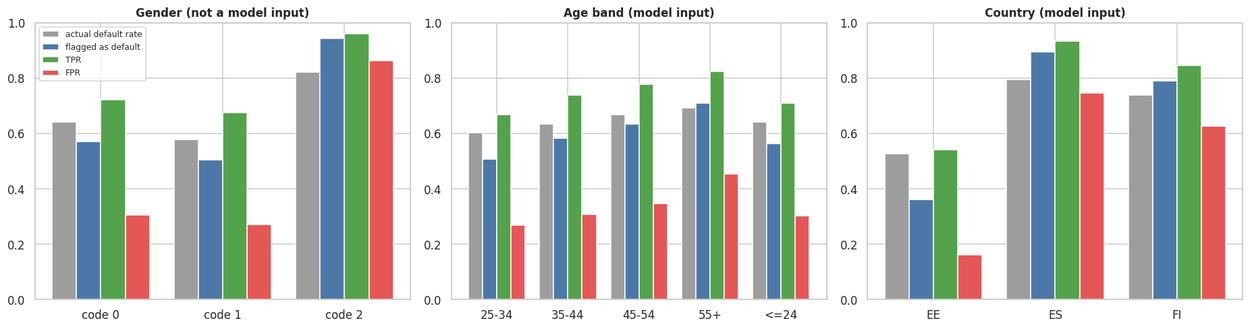

In [ ]:
def group_report(groups, name, mask=None):
    keep_rows = np.ones(len(y_arr), dtype=bool) if mask is None else np.asarray(mask)
    d = pd.DataFrame({"group": np.asarray(groups)[keep_rows] if mask is None else np.asarray(groups),
                      "y": y_arr[keep_rows], "p": p_test[keep_rows], "flag": pred_test[keep_rows], "review": is_conflict[keep_rows]})
    out = []
    for g, s in d.groupby("group", observed=True):
        if len(s) < 200 or s["y"].nunique() < 2:
            continue
        out.append({"attribute": name, "group": str(g), "applicants": len(s), "actual default rate": s["y"].mean(),
                    "flagged as default": s["flag"].mean(), "TPR (defaulters caught)": s.loc[s.y == 1, "flag"].mean(),
                    "FPR (good borrowers flagged)": s.loc[s.y == 0, "flag"].mean(), "ROC-AUC": roc_auc_score(s["y"], s["p"]),
                    "sent to human review": s["review"].mean()})
    return pd.DataFrame(out)

gender_lbl = meta_test["Gender"].map(lambda v: "missing" if pd.isna(v) else f"code {int(v)}")
age_lbl = pd.cut(meta_test["Age"], [0, 24, 34, 44, 54, 200], labels=["<=24", "25-34", "35-44", "45-54", "55+"])
fair = pd.concat([group_report(gender_lbl, "Gender (not a model input)"),
                  group_report(age_lbl, "Age band (model input)"),
                  group_report(meta_test["Country"], "Country (model input)")], ignore_index=True)
display(fair.set_index(["attribute", "group"]).style.format({
    "actual default rate": "{:.1%}", "flagged as default": "{:.1%}", "TPR (defaulters caught)": "{:.1%}",
    "FPR (good borrowers flagged)": "{:.1%}", "ROC-AUC": "{:.3f}", "sent to human review": "{:.1%}"}))

summ = []
for a, g in fair.groupby("attribute", sort=False):
    appr = 1 - g["flagged as default"]
    summ.append({"attribute": a, "approval-rate ratio (min / max)": appr.min() / appr.max(),
                 "TPR gap (max - min)": g["TPR (defaulters caught)"].max() - g["TPR (defaulters caught)"].min(),
                 "FPR gap (max - min)": g["FPR (good borrowers flagged)"].max() - g["FPR (good borrowers flagged)"].min(),
                 "AUC range": g["ROC-AUC"].max() - g["ROC-AUC"].min()})
fair_summary = pd.DataFrame(summ).set_index("attribute")
display(fair_summary.style.format("{:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, (a, g) in zip(axes, fair.groupby("attribute", sort=False)):
    x = np.arange(len(g)); w = 0.2
    ax.bar(x - 1.5 * w, g["actual default rate"], w, label="actual default rate", color="#9D9D9D")
    ax.bar(x - 0.5 * w, g["flagged as default"], w, label="flagged as default", color="#4C78A8")
    ax.bar(x + 0.5 * w, g["TPR (defaulters caught)"], w, label="TPR", color="#54A24B")
    ax.bar(x + 1.5 * w, g["FPR (good borrowers flagged)"], w, label="FPR", color="#E45756")
    ax.set_xticks(x); ax.set_xticklabels(g["group"]); ax.set_title(a); ax.set_ylim(0, 1)
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); save_fig(fig, "16_fairness_audit"); plt.show()

**Reading the audit.** The model never sees gender, yet the audit still shows large differences, and almost all of them trace back to **country**. Spanish applicants are flagged as likely defaulters 89.6% of the time against 36.2% for Estonians, and the false-positive rate (good borrowers wrongly flagged) is 74.5% in Spain, 62.7% in Finland and 16.2% in Estonia. The "unknown gender" group (code 2) shows a 94.3% flag rate and 86.2% false-positive rate, but 2,109 of its 2,110 applicants are Spanish, so this is not a gender effect.

Inside each country the gender picture is much milder. In Estonia, code 0 is flagged 38.3% against 31.5% for code 1, which tracks the actual default rates (55.0% against 47.7%). In Spain the same two codes differ by about 7 points in false-positive rate (67.9% against 61.3%). One gap does remain unexplained inside Spain: applicants with no recorded gender (code 2) have a false-positive rate of 86.5%, about 19 points above the largest other Spanish group (code 0), and a lower AUC (0.671). The data here cannot say why. It may reflect how those loans were sourced, and it deserves follow-up before deployment.

Age shows a real gradient. Applicants aged 55 and over are wrongly flagged 45.4% of the time against 26.8% for ages 25 to 34, and the model also ranks the 55+ group less well (AUC 0.762 against 0.789 for ages 35 to 44).

### Reading the audit correctly: gender code 2 is really Spain
The "unknown gender" group (code 2) looks alarming, but it is almost entirely Spanish loans (Bondora did not record gender for them). Before reading anything into a gender gap, the next table looks at gender **inside each country**, where this confound disappears.

In [ ]:
ctab = pd.crosstab(meta_test["Gender"].map(lambda v: "missing" if pd.isna(v) else f"code {int(v)}"), meta_test["Country"])
note("**Test applicants by gender code and country:**")
display(ctab)

within = pd.concat([group_report(gender_lbl[(meta_test["Country"] == c).values], f"Gender within {c}", mask=(meta_test["Country"] == c).values)
                    for c in ["EE", "ES", "FI"]], ignore_index=True)
display(within.set_index(["attribute", "group"]).style.format({
    "actual default rate": "{:.1%}", "flagged as default": "{:.1%}", "TPR (defaulters caught)": "{:.1%}",
    "FPR (good borrowers flagged)": "{:.1%}", "ROC-AUC": "{:.3f}", "sent to human review": "{:.1%}"}))

**Test applicants by gender code and country:**

Country,EE,ES,FI,SK
Gender,,,,
code 0,7982,2150,3729,36
code 1,3576,426,2026,30
code 2,1,2109,0,0
missing,4,0,0,0


### Why the country gap exists, and one way to narrow it
The model is **well calibrated inside each country** (average predicted risk matches the observed default rate), so it is not "wrong" about Spain or Finland. The gap appears because a single global threshold is applied to markets whose underlying default rates differ a lot. In a high-default market almost everyone lands above the line, including many good borrowers.

One mitigation that needs no protected attribute: choose a threshold **per country** so that the same share of *good borrowers* is wrongly flagged everywhere (equal false-positive rate, equal burden on the creditworthy). Thresholds are learned on out-of-fold training predictions only. Countries with under 1,000 training loans keep the global threshold.

In [ ]:
cal = pd.DataFrame({"country": meta_test["Country"].values, "p": p_test, "y": y_arr}).groupby("country").agg(
    applicants=("y", "size"), mean_predicted=("p", "mean"), observed_default_rate=("y", "mean"))
note("**Calibration by country (test):**")
display(cal.style.format({"mean_predicted": "{:.3f}", "observed_default_rate": "{:.3f}"}))

tr_country = meta_train["Country"].values
good_tr = y_train.values == 0
global_fpr = (oof[good_tr] >= THRESHOLD).mean()
thr_by_country = {}
for c in pd.Series(tr_country).unique():
    sel = (tr_country == c)
    thr_by_country[c] = float(np.quantile(oof[sel & good_tr], 1 - global_fpr)) if sel.sum() >= 1000 else THRESHOLD
print(f"Target false-positive rate (global threshold {THRESHOLD:.2f} on training OOF): {global_fpr:.1%}")
print("Per-country thresholds:", {k: round(v, 3) for k, v in thr_by_country.items()})

thr_vec = meta_test["Country"].map(thr_by_country).to_numpy()
pred_eq = (p_test >= thr_vec).astype(int)

def rates(pred, groups):
    d = pd.DataFrame({"g": np.asarray(groups), "y": y_arr, "f": pred})
    return d.groupby("g").apply(lambda s: pd.Series({"flagged": s["f"].mean(), "TPR": s.loc[s.y == 1, "f"].mean(), "FPR": s.loc[s.y == 0, "f"].mean()}))

r_glob, r_eq = rates(pred_test, meta_test["Country"]), rates(pred_eq, meta_test["Country"])
mit = pd.concat({"global threshold": r_glob, "per-country threshold": r_eq}, axis=1)
display(mit.style.format("{:.1%}"))

mit_summary = pd.DataFrame({
    "balanced accuracy": [balanced_accuracy_score(y_test, pred_test), balanced_accuracy_score(y_test, pred_eq)],
    "FPR gap across EE/ES/FI": [r_glob.loc[["EE", "ES", "FI"], "FPR"].max() - r_glob.loc[["EE", "ES", "FI"], "FPR"].min(),
                                r_eq.loc[["EE", "ES", "FI"], "FPR"].max() - r_eq.loc[["EE", "ES", "FI"], "FPR"].min()],
    "TPR gap across EE/ES/FI": [r_glob.loc[["EE", "ES", "FI"], "TPR"].max() - r_glob.loc[["EE", "ES", "FI"], "TPR"].min(),
                                r_eq.loc[["EE", "ES", "FI"], "TPR"].max() - r_eq.loc[["EE", "ES", "FI"], "TPR"].min()],
    "overall share flagged": [pred_test.mean(), pred_eq.mean()],
}, index=["Global threshold", "Per-country thresholds (equal FPR)"])
display(mit_summary.style.format("{:.3f}"))

**Calibration by country (test):**

,applicants,mean_predicted,observed_default_rate
country,,,
EE,11563,0.528,0.527
ES,4685,0.793,0.796
FI,5755,0.729,0.739
SK,66,0.894,0.924


Target false-positive rate (global threshold 0.65 on training OOF): 33.5%
Per-country thresholds: {'FI': 0.748, 'ES': 0.82, 'EE': 0.523, 'SK': 0.65}


,balanced accuracy,FPR gap across EE/ES/FI,TPR gap across EE/ES/FI,overall share flagged
Global threshold,0.709,0.583,0.392,0.589
Per-country thresholds (equal FPR),0.665,0.020,0.174,0.536


**Reading the mitigation.** The model is well calibrated inside each country (average predicted risk 0.528, 0.793 and 0.729 against observed rates of 0.527, 0.796 and 0.739), so the country gap is not a miscalibration. It comes from using one threshold across markets with different base rates. Setting a threshold for each country so that about a third of good borrowers are flagged everywhere (the global rate on training data was 33.5%) brings the false-positive rates to 32.5% (Estonia), 31.1% (Spain) and 33.2% (Finland). The gap across countries falls from 0.583 to 0.020.

There is no free lunch, and the notebook should not hide it. Balanced accuracy drops from 0.709 to 0.665, the share flagged falls from 58.9% to 53.6%, and fewer defaulters are caught in the high-risk markets (recall 58.3% in Spain and 57.7% in Finland, against 93.4% and 84.6% before). Equalising the burden on good borrowers means accepting more defaults in Spain and Finland. Whether that is the right trade is a policy choice for the lender and the regulator, and it should be made on the lender's actual costs, not on this notebook. The 66 Slovak loans are too few to set a threshold, so they keep the global one.

### Age: does removing the feature close the gap?
Age is a model input, and the audit showed older applicants being wrongly flagged more often. Per-age thresholds are not an option (using a protected attribute at decision time is exactly what fairness rules forbid), so the test here is **fairness through unawareness**: refit without Age and check what changes. To keep the comparison fair, the no-Age model is given the same overall flag rate as the champion.

In [ ]:
noage = build_pipe(clone(final_pipe.named_steps["clf"]), drop=("Age",)).fit(X_train, y_train)
p_noage = noage.predict_proba(X_test)[:, 1]
thr_noage = float(np.quantile(p_noage, 1 - pred_test.mean()))
flag_noage = (p_noage >= thr_noage).astype(int)

def age_table(flag, score):
    d = pd.DataFrame({"band": age_lbl.to_numpy(), "y": y_arr, "f": flag, "p": score})
    return d.groupby("band", observed=True).apply(lambda s: pd.Series({
        "FPR": s.loc[s.y == 0, "f"].mean(), "TPR": s.loc[s.y == 1, "f"].mean(), "AUC": roc_auc_score(s["y"], s["p"])}))

at = pd.concat({"with Age (champion)": age_table(pred_test, p_test), "without Age": age_table(flag_noage, p_noage)}, axis=1)
display(at.style.format("{:.3f}"))
age_cmp = pd.DataFrame({
    "overall ROC-AUC": [roc_auc_score(y_test, p_test), roc_auc_score(y_test, p_noage)],
    "FPR gap across age bands": [at["with Age (champion)"]["FPR"].max() - at["with Age (champion)"]["FPR"].min(),
                                 at["without Age"]["FPR"].max() - at["without Age"]["FPR"].min()],
}, index=["With Age (champion)", "Without Age"])
display(age_cmp.style.format("{:.3f}"))

,overall ROC-AUC,FPR gap across age bands
With Age (champion),0.781,0.186
Without Age,0.777,0.159


**Reading the Age test.** Removing Age lowers overall ROC-AUC slightly (0.781 to 0.777) and narrows the gap across age bands from 0.186 to 0.159, but it does not close it. Applicants 55 and over are still wrongly flagged most often (43.0%, against 45.4% before), and some of the effect shifts elsewhere: the youngest group, which had a recall of 71.0%, drops to 63.3%. Other features such as employment tenure and loan history probably carry part of the age signal, although this notebook did not test that directly. The honest summary is that "just remove the sensitive column" is not a solution. Real mitigation needs the audit to be repeated whenever the model changes.

## 3.6 Save everything the next steps need
The website and deployment steps need the fitted pipeline, the threshold, the feature schema and the symbolic rule base. Saving them now, and **testing the saved pipeline in a brand-new Python process**, catches pickling and import problems before they cost time later.

In [ ]:
import joblib

joblib.dump(final_pipe, f"{ART_DIR}/default_risk_pipeline.joblib")
joblib.dump(scorecard, f"{ART_DIR}/symbolic_scorecard.joblib")
joblib.dump(mono_pipe, f"{ART_DIR}/default_risk_pipeline_monotone.joblib")

schema_json = {
    "model": champion_name, "positive_class": "default (1)", "decision_threshold": THRESHOLD,
    "symbolic_scorecard_threshold": THR_SYM,
    "raw_input_columns": lu.RAW_INPUT_COLUMNS, "numeric": lu.NUMERIC_ALL, "categorical": lu.CATEGORICAL,
    "sdgs": ["SDG 8 Decent Work and Economic Growth", "SDG 10 Reduced Inequalities"],
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "symbolic_rules": [{"name": r["name"], "meaning": r["text"], "expected_direction": r["expected"],
                        "scorecard_weight": float(weights.loc[r["name"], "weight (log-odds)"])} for r in lu.RULEBOOK],
    "mined_rule_list_fidelity": float(fidelity_test),
    "knowledge_constrained_variant": {"file": "default_risk_pipeline_monotone.joblib", "roc_auc_test": float(roc_auc_score(y_test, p_mono)),
                                      "monotone_features": MONO},
    "per_country_thresholds_equal_fpr": thr_by_country,
}
with open(f"{ART_DIR}/model_card.json", "w") as fh:
    json.dump(schema_json, fh, indent=2)

all_cv.to_csv(f"{ART_DIR}/cv_results.csv")
test_metrics.to_csv(f"{ART_DIR}/test_metrics.csv", header=["value"])
rules_df.to_csv(f"{ART_DIR}/mined_rules.csv")
fair.to_csv(f"{ART_DIR}/fairness_audit.csv", index=False)
alignment.to_csv(f"{ART_DIR}/knowledge_alignment.csv")
X_test.head(200).to_csv(f"{ART_DIR}/sample_applicants.csv")

check = r'''
import joblib, pandas as pd, json
card = json.load(open("artifacts/model_card.json"))
pipe = joblib.load("artifacts/default_risk_pipeline.joblib")
X = pd.read_csv("artifacts/sample_applicants.csv", index_col=0, dtype={c: str for c in card["categorical"]})
print(json.dumps([float(v) for v in pipe.predict_proba(X)[:, 1]]))
'''
out = subprocess.run([sys.executable, "-c", check], capture_output=True, text=True)
assert out.returncode == 0, out.stderr[-800:]
fresh = np.array(json.loads(out.stdout.strip().splitlines()[-1]))
ref = final_pipe.predict_proba(X_test.head(200))[:, 1]
print("Fresh-process reload OK:", len(fresh), "applicants scored")
print("Max difference vs the in-memory model:", float(np.abs(fresh - ref).max()))
assert np.allclose(fresh, ref, atol=1e-6)
print("Saved files:", sorted(os.listdir(ART_DIR)))

Fresh-process reload OK: 200 applicants scored
Max difference vs the in-memory model: 0.0
Saved files: ['cv_results.csv', 'default_risk_pipeline.joblib', 'default_risk_pipeline_monotone.joblib', 'fairness_audit.csv', 'knowledge_alignment.csv', 'mined_rules.csv', 'model_card.json', 'sample_applicants.csv', 'symbolic_scorecard.joblib', 'test_metrics.csv']


---
# 4. Summary, limitations and next steps

## What was built
A default-risk model for the Bondora loan book and a three-part explanation layer.

* **Data (section 1).** 179,235 loans were reduced to 110,342 with a trustworthy outcome (final result, at least a year of history). All 112 columns were governed by an explicit rule: 37 post-origination columns were kept out as leakage, six fields Bondora stopped collecting and ten empty-in-practice fields were removed, protected attributes were held out of the model, and a quirk in the monthly payment (zeros from 2013 and 2014) was found and fixed.
* **Model (section 2).** Seven model families were compared by 5-fold cross-validation. The tuned XGBoost was chosen by a rule set in advance and scored ROC-AUC **0.781** on the untouched test set (95% interval 0.775 to 0.787). The observed default rate climbs from 14% to 92% across risk deciles.
* **Explanation (section 3).** SHAP (exact, additive), LIME (independent check, 92% directional agreement with SHAP) and neurosymbolic XAI: 14 mined rules reproducing 78.7% of the champion's decisions, a transparent nine-rule scorecard, expert-constraint tests that exposed violations for 6% to 43% of applicants depending on the rule, a knowledge-constrained variant that fixes the three supported ones for 0.004 AUC, and per-applicant reasoning reports.
* **Fairness audit (section 3.5).** Disparities are driven mainly by country, not by gender. A per-country threshold narrows the false-positive gap from 0.583 to 0.020 at a measured cost.

## How this serves the two SDGs
**SDG 8 (target 8.10, access to financial services).** A model that ranks risk well (14% to 92% across deciles) lets a lender price and approve loans for first-time and thin-file borrowers with eyes open, and the knowledge-constrained variant makes the pricing logic predictable. **SDG 10 (reduced inequalities).** Every decision comes with reasons in the applicant's own units, the model is audited by country, gender and age, and the cost of one fairness fix is stated openly instead of hidden.

## Limitations to state openly
1. **The outcome is defined on resolved loans only.** The 64% default rate is higher than the platform-wide rate, and the model ranks risk among loans that reached a final outcome. It is not an estimate of the platform's overall default rate.
2. **Time drift is large.** ROC-AUC falls from 0.781 (random split) to 0.715 (train up to 2018, test on later loans). Any deployed model needs monitoring and retraining.
3. **Seasoning is imperfect.** About half of all defaults take more than 290 days, so even a 12-month window leaves some late defaults unseen in the youngest loans.
4. **Category codes are not labelled.** Education, verification and similar fields are used as published codes. The Bondora data dictionary should be added before the codes are shown to end users.
5. **The rule base is small and hand-written.** The nine rules and their thresholds are analyst choices. Four rules conflicted with the data, which is a finding, but a larger and better-validated rule base would be needed in practice.
6. **The agreement check is not an efficient triage tool.** Reviewing the model's own least-confident cases beats it (77.2% against 73.9% accuracy on the remaining decisions).
7. **Fairness is only partly resolved.** The Spanish no-gender group, and the older-age gap, are not explained by anything this notebook tested.
8. **The threshold is statistical.** A lender would set it from the cost of defaults against lost interest.

## Handing over to the next steps
Step 4 (website) and step 5 (deployment) need only the `artifacts/` folder and `loan_utils.py`:

| File | Purpose |
|---|---|
| `default_risk_pipeline.joblib` | Champion: raw applicant fields in, default probability out |
| `default_risk_pipeline_monotone.joblib` | Knowledge-constrained variant |
| `symbolic_scorecard.joblib` | Weighted-rule scorecard for the reasoning view |
| `model_card.json` | Threshold, feature schema, rule weights, test metrics, per-country thresholds |
| `mined_rules.csv`, `fairness_audit.csv`, `knowledge_alignment.csv`, `cv_results.csv`, `test_metrics.csv` | Reporting tables |
| `sample_applicants.csv` | 200 example inputs to test the website against |

A reload test in a fresh Python process (previous cell) confirmed the saved pipeline gives identical scores. The full notebook takes roughly 25 minutes on a single CPU core, most of it in cross-validation and tuning.